In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import sys


import pickle

from PIL import Image
import os
import cv2
import random
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist,squareform
import networkx as nx
import random
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from scipy.spatial import cKDTree
from sklearn.metrics import mean_squared_error
from itertools import product
from tqdm import tqdm
from pathlib import Path
from matplotlib.image import imread
from sklearn.metrics.pairwise import euclidean_distances
import json
from sklearn.utils import shuffle

import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import euclidean_distances


In [2]:
EMBEDDING_DIM = 4

# Functions

In [3]:
def knn_graph(matrix, k=5):
    G = nx.Graph()
    nbrs = NearestNeighbors(n_neighbors=k).fit(matrix)
    distances, indices = nbrs.kneighbors(matrix)
    
    for i in range(len(matrix)):
        G.add_node(i, pos=(matrix[i, 0], matrix[i, 1]))
        for j in indices[i]:
            if i != j:
                G.add_edge(i, j, weight=distances[i][np.where(indices[i] == j)[0][0]])
    
    return G

def plot_knn_graph(G,highlighted_nodes,polygon_mask):
    
    # Create a color map for nodes
    highlight_color = "#FF4500"
    node_colors = [highlight_color if node in highlighted_nodes else 'lightblue' for node in G.nodes()]
    #if pos == None:    
    pos = nx.get_node_attributes(G, 'pos')
    # Draw the graph
    fig,ax = plt.subplots(figsize=(8, 8))
    ax.imshow(polygon_mask, cmap='gray', alpha=0.3)
    nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax
    
def plot_scatter(pos,highlighted_nodes,polygon_mask):
    
    # Create a color map for nodes
    highlight_color = "#FF4500"
    node_colors = [highlight_color if i in highlighted_nodes else 'lightblue' for i in np.arange(1000)]
    #if pos == None:    
    #pos = nx.get_node_attributes(G, 'pos')
    # Draw the graph
    fig,ax = plt.subplots(figsize=(8, 8))
    ax.imshow(polygon_mask, cmap='gray', alpha=0.3)
    ax.scatter(pos[:,0],pos[:,1],s = 50,c = node_colors)
    #nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax


    #nx.draw(G, pos, with_labels=False, node_size=100, node_color='lightblue', edge_color='gray', alpha=0.6)
    #plt.show()

def plot_knn_graph_pos(G,highlighted_nodes,pos):
    #pos = nx.get_node_attributes(G, 'pos')
    highlight_color = "#FF4500"
    node_colors = [highlight_color if node in highlighted_nodes else 'lightblue' for node in G.nodes()]
    fig,ax = plt.subplots(figsize=(8, 8))
    nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax
    
def compute_kernel_matrix(X,k):
    D = squareform(pdist(X))
    # D_s = np.argsort(D,axis=1)
    # sig = np.median(D_s[:,(k+1)])
    D_sorted = np.sort(D, axis=1) 
    k_nn_distances = D_sorted[:, k] 
    sig = np.median(k_nn_distances)
    print("SIG:", sig) 
    K = np.exp(-D**2/sig**2)    
    return K

def compute_laplacian(K):
    D_inv = np.diag(np.sum(K,axis = 1)**(-0.5))
    L = D_inv@K@D_inv
    return L

def compute_leading_eigenvectors(L, d):
    lam,v = np.linalg.eigh(L)
    sort_idx = np.argsort(lam)[::-1]
    lam = lam[sort_idx]
    v = v[:,sort_idx]
    return lam[:d],v[:,:d]

# def segment_inside_mask(mask, p0, p1, thickness=1, thresh=128):
#     """
#     Return True if the full line between p0->p1 lies inside mask>thresh.
#     p0, p1 are (x, y) coordinates.
#     """
#     H, W = mask.shape[:2]
#     tmp = np.zeros((H, W), np.uint8)
#     cv2.line(tmp, (int(p0[0]), int(p0[1])), (int(p1[0]), int(p1[1])), 255, thickness)
#     walkable = mask > thresh
#     return np.all(walkable[tmp > 0])

def remove_edges_outside_mask(G, mask, thickness=2, thresh=128, verbose=True):
    """
    Removes edges from G whose line segments leave the mask.
    Edits G in place.
    """
    pos = nx.get_node_attributes(G, "pos")
    to_remove = []
    
    for u, v in list(G.edges()):
        if u not in pos or v not in pos:
            to_remove.append((u, v))
            continue
        
        if not segment_inside_mask(mask, pos[u], pos[v], thickness=thickness, thresh=thresh):
            to_remove.append((u, v))
    
    G.remove_edges_from(to_remove)
    
    if verbose:
        print(f"❌ Removed {len(to_remove)} edges that crossed outside the mask "
              f"({len(G.edges())} remain)")
    return to_remove


    

In [236]:

def load_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (image.shape[1] // 4, image.shape[0] // 4))  # Reduce size by half
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    return image, hsv

def detect_shapes(image):
    polygon_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    rectangles = []
    circles = []
    
    # Define color ranges
    black_lower = np.array([0, 0, 0])
    black_upper = np.array([180, 255, 50])
    blue_lower = np.array([100, 150, 50])
    blue_upper = np.array([140, 255, 255])
    green_lower = np.array([40, 50, 50])
    green_upper = np.array([90, 255, 255])
    
    # Detect black polygon
    black_mask = cv2.inRange(image, black_lower, black_upper)
    contours, _ = cv2.findContours(black_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        cv2.drawContours(polygon_mask, [contour], -1, 255, thickness=cv2.FILLED)
    
    # Detect blue rectangles
    blue_mask = cv2.inRange(image, blue_lower, blue_upper)
    contours, _ = cv2.findContours(blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        rectangles.append((x, y, w, h))
    
    # Detect green circles
    green_mask = cv2.inRange(image, green_lower, green_upper)
    contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        (x, y), radius = cv2.minEnclosingCircle(contour)
        circles.append((int(x), int(y), int(radius)))
    
    return polygon_mask, rectangles, circles


def generate_random_points(mask, num_points=1000):
    points = []
    h, w = mask.shape
    while len(points) < num_points:
        x, y = random.randint(0, w-1), random.randint(0, h-1)
        if mask[y, x] == 255:
            points.append((x, y))
    return points

# def build_graph(mask, rectangles):
#     G = nx.grid_2d_graph(mask.shape[0], mask.shape[1])
#     for x, y, w, h in rectangles:
#         for i in range(x, x+w):
#             for j in range(y, y+h):
#                 if (j, i) in G:                    
#                     G.remove_node((j, i))
#     return G


def build_graph(mask, rectangles=None):
    """
    Build a grid graph from a binary mask.

    Parameters
    ----------
    mask : np.ndarray (H x W)
        Binary mask (1 or 255 = inside / walkable area).
    rectangles : list of (x, y, w, h), optional
        Rectangles to remove as obstacles. If None, obstacles are taken
        from where mask == 0 (i.e., the inverse of mask).

    Returns
    -------
    G : networkx.Graph
        Grid graph with nodes removed for obstacle regions.
    """
    H, W = mask.shape[:2]
    G = nx.grid_2d_graph(H, W)

    # Case 1: explicit rectangles
    if rectangles is not None and len(rectangles) > 0:
        for x, y, w, h in rectangles:
            for i in range(x, x + w):
                for j in range(y, y + h):
                    if (j, i) in G:
                        G.remove_node((j, i))

    # Case 2: implicit obstacles from mask (0 = blocked)
    else:
        blocked = np.where(mask == 0)
        for j, i in zip(blocked[0], blocked[1]):  # note (row, col)
            if (j, i) in G:
                G.remove_node((j, i))
    

    return G

            
def segment_inside_mask(mask, p0, p1, thickness=2, thresh=128):
    H, W = mask.shape[:2]
    tmp = np.zeros((H, W), np.uint8)
    cv2.line(tmp, (int(p0[0]), int(p0[1])), (int(p1[0]), int(p1[1])), 255, thickness)
    walkable = mask > thresh
    return np.all(walkable[tmp > 0])

def create_complete_graph_from_points(mask, points, obey_mask=True, thickness=2):
    """
    points: np.ndarray (N, 2) in (x,y) order or DataFrame
    mask: 2D uint8, 0/255
    returns: networkx.Graph with all nodes and edges
    """
    # --- 1. Standardization Step ---
    if isinstance(points, pd.DataFrame):
        # Check for common column names. 
        # Note: The original docstring said "in (y, x) order". 
        # If your DF has 'x' and 'y' columns, we explicitly map them.
        if 'x' in points.columns and 'y' in points.columns:
            # We extract them in (y, x) order to match the original function's logic
            # where: for i, (y, x) in enumerate(points)
            points_data = points[['x', 'y']].values
        else:
            # If no labels, just convert to numpy array assuming (y, x) structure
            points_data = points.values
    else:
        # It's already an array or list
        points_data = points
        
    G = nx.Graph()
    N = len(points)
    if N == 0:
        print("⚠️ no points given")
        return G

    # 1) add nodes with pos
    for i, (x,y) in enumerate(points_data):
        G.add_node(i, pos=(float(x), float(y)))

    # 2) connect everyone to everyone
    for i in range(N):
        x1, y1 = G.nodes[i]["pos"]
        for j in range(i+1, N):
            x2, y2 = G.nodes[j]["pos"]

            if obey_mask:
                if not segment_inside_mask(mask, (x1, y1), (x2, y2), thickness=thickness):
                    continue

            dist = float(np.hypot(x2 - x1, y2 - y1))
            G.add_edge(i, j, weight=dist)

    print(f"✅ created graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G

def build_graph_from_points(mask, points, radius=None, k=6):
    """
    Build a graph on sampled points.
    - If radius is given -> connect pairs within that distance.
    - Else -> connect each point to its k nearest neighbors.
    Edge weight = Euclidean distance.
    """
    G = nx.Graph()
    if len(points) == 0:
        return G

    # add nodes with positions (x,y) for plotting
    for i, (y, x) in enumerate(points):
        G.add_node(i, pos=(int(x), int(y)))

    tree = cKDTree(points)

    if radius is not None:
        # radius graph
        for i, j in tree.query_pairs(r=radius):
            (y1, x1), (y2, x2) = points[i], points[j]
            if mask[int(y1), int(x1)] > 0 and mask[int(y2), int(x2)] > 0:
                w = float(np.hypot(x2 - x1, y2 - y1))
                G.add_edge(i, j, weight=w)
    else:
        # k-NN graph (k>=1). query k+1 because the nearest neighbor is the point itself
        k = max(1, int(k))
        dists, idxs = tree.query(points, k=k+1)
        for i, (row_d, row_idx) in enumerate(zip(dists, idxs)):
            for d, j in zip(row_d[1:], row_idx[1:]):  # skip self
                (y1, x1), (y2, x2) = points[i], points[j]
                if mask[int(y1), int(x1)] > 0 and mask[int(y2), int(x2)] > 0:
                    G.add_edge(i, j, weight=float(d))
    
    

    return G


def compute_shortest_paths(G, points, circles):
    distance_matrix = np.zeros((len(points), len(circles)))
    for i, (px, py) in enumerate(points):
        if (i==10):
            print(i)
        for j, (cx, cy, _) in enumerate(circles):
            try:
                path_length = nx.shortest_path_length(G, (py, px), (cy, cx))
            except nx.NetworkXNoPath:
                path_length = float('inf')
            distance_matrix[i, j] = path_length
    return distance_matrix

def plot_original_image(file_path, site, floor):
    img_path = create_img_path(file_path, site, floor)
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    
    # handle transparency
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    
    if img.shape[2] == 4:
        img_rgb = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2RGB)
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title("Original Floorplan Image")
    plt.axis("off")
    plt.show()

def create_img_path(files_dir_path, site,floor):
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    img_path = next((Path(files_dir_path)/site/fstr).glob("floor_image.*"))
    return img_path

In [237]:
# ---------- 1) INSIDE via alpha outer contour ----------
def inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr=10, close_ks=5):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    if img.ndim < 3 or img.shape[2] < 4:
        raise ValueError("PNG with alpha is required.")

    H, W = img.shape[:2]
    alpha = img[:, :, 3]
    opaque = (alpha > alpha_clear_thr).astype(np.uint8) * 255

    if close_ks > 0:
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
        opaque = cv2.morphologyEx(opaque, cv2.MORPH_CLOSE, k)

    cnts, _ = cv2.findContours(opaque, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return np.zeros((H, W), np.uint8)

    mall_cnt = max(cnts, key=cv2.contourArea)
    inside = np.zeros((H, W), np.uint8)
    cv2.drawContours(inside, [mall_cnt], -1, 255, thickness=cv2.FILLED)
    return inside

# ---------- 2) “Store” detection (your gates) ----------
def detect_store_mask(
    img_bgr,
    inside_mask,
    *,
    black_V_max=110, close_iters=3, dilate_black_px=1,
    white_S_max=80,  white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
    purple_H=(120,175), purple_S_min=20, purple_V_min=105,
    min_area_px=80, shrink_px=1
):
    """Return mask (255) for store polygons inside the black frame."""
    H, W = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # black outline/walls
    black = cv2.inRange(hsv, np.array([0,0,0], np.uint8),
                             np.array([180,255,black_V_max], np.uint8))
    black = cv2.morphologyEx(black, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=close_iters)
    if dilate_black_px > 0:
        k = 2*dilate_black_px+1
        black = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # broad light/white
    white = cv2.inRange(hsv, np.array([0,0,white_V_min], np.uint8),
                             np.array([180,white_S_max,255], np.uint8))

    # pastel gate: low S, high V (any hue)
    s = hsv[...,1]; v = hsv[...,2]
    pastel = np.zeros((H,W), np.uint8)
    pastel[(s <= pastel_S_max) & (v >= pastel_V_min)] = 255

    # explicit hues
    def hue_mask(h_lo, h_hi, s_min, v_min):
        return cv2.inRange(hsv,
                           np.array([h_lo, s_min, v_min], np.uint8),
                           np.array([h_hi, 255, 255], np.uint8))
    cyan   = hue_mask(*cyan_H,   cyan_S_min,   cyan_V_min)
    blue   = hue_mask(*blue_H,   blue_S_min,   blue_V_min)
    purple = hue_mask(*purple_H, purple_S_min, purple_V_min)

    # union, constrained to inside and not on the black walls
    stores = white | pastel | cyan | blue | purple
    stores = cv2.bitwise_and(stores, inside_mask)
    stores = cv2.bitwise_and(stores, cv2.bitwise_not(black))

    # clean + optional shrink so we don't touch wall pixels
    stores = cv2.morphologyEx(stores, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)

    if shrink_px > 0:
        k = 2*shrink_px+1
        stores = cv2.erode(stores, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # area filter
    cnts, _ = cv2.findContours(stores, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    keep = np.zeros_like(stores)
    for c in cnts:
        if cv2.contourArea(c) >= min_area_px:
            cv2.drawContours(keep, [c], -1, 255, thickness=cv2.FILLED)
    return keep

# ---------- 3) Final: inside minus stores = corridors/voids ----------
def get_corridor_mask(img_path,
                      alpha_clear_thr=10, close_ks=5,
                      **store_gate_kwargs):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img

    inside = inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr, close_ks)
    store_mask = detect_store_mask(bgr, inside, **store_gate_kwargs)
    corridor = cv2.bitwise_and(inside, cv2.bitwise_not(store_mask))
    return corridor, store_mask, inside

# ---------- Overlay helper ----------
def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img
    overlay = base.copy()
    overlay[mask>0] = (0,255,255)  # yellow (BGR)
    out = cv2.addWeighted(overlay, alpha, base, 1-alpha, 0)
    if out_path: cv2.imwrite(out_path, out)
    return out

def thin_black_text_mask(img_bgr, inside_mask=None,
                         v_thr=105, s_thr=110,  # what counts as "black"
                         min_stroke_px=4):      # remove strokes thinner than ~this width
    """
    Returns 255 where black strokes are *thin* (likely text).
    min_stroke_px is the approximate full stroke width in pixels.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    V, S = hsv[:, :, 2], hsv[:, :, 1]

    # Black pixels (very dark & not saturated)
    black = ((V < v_thr) & (S < s_thr)).astype(np.uint8) * 255

    # Optional: only care about thin black *inside* the mall
    if inside_mask is not None:
        black = cv2.bitwise_and(black, inside_mask)

    # Distance transform on black foreground
    # (distance ~ half the local stroke width)
    dist = cv2.distanceTransform(black, cv2.DIST_L2, 3)

    # Pixels with half-width < min_stroke_px/2 are thin
    thin = (dist < (min_stroke_px / 2.0)).astype(np.uint8) * 255

    # Clean specks
    thin = cv2.morphologyEx(thin, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)
    return thin

def corridors_without_text(img_path,get_inside_fn,      # your inside-mask function
                           detect_stores_fn,   # your store mask function (gates)
                           **kwargs_for_stores):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img

    # 1) inside
    inside = get_inside_fn(img_path)

    # 2) stores
    stores = detect_stores_fn(bgr, inside, **kwargs_for_stores)

    # 3) corridors (inside minus stores)
    corridor = cv2.bitwise_and(inside, cv2.bitwise_not(stores))

    # 4) remove thin black strokes (text)
    thin_text = thin_black_text_mask(bgr, inside_mask=inside,
                                     v_thr=105, s_thr=110,   # tune if needed
                                     min_stroke_px=4)        # ~4–6 works well
    corridor = cv2.bitwise_and(corridor, cv2.bitwise_not(thin_text))
    return corridor

# Use your store detector (the v3 gates you posted):
def stores_fn(img_bgr, inside_mask, **k):
    return detect_store_mask(
        img_bgr, inside_mask,
        black_V_max=110, close_iters=3, dilate_black_px=1,
        white_S_max=80, white_V_min=185,
        pastel_S_max=90, pastel_V_min=165,
        cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
        blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
        purple_H=(120,175), purple_S_min=20, purple_V_min=105,
        min_area_px=80, shrink_px=1
    )

def sample_points_from_mask(mask, n=100, value_threshold=128, seed=None):
    """
    Randomly sample N valid (y,x) points from a binary mask.

    Parameters
    ----------
    mask : np.ndarray (H x W)
        Binary or grayscale mask. Non-zero = valid region.
    n : int
        Number of points to sample.
    value_threshold : int
        Minimum pixel value to count as 'inside' (default 128).
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    pts : np.ndarray of shape (n, 2)
        Randomly sampled points in (y, x) order.
    """
    if seed is not None:
        np.random.seed(seed)

    # Find all valid coordinates
    ys, xs = np.where(mask > value_threshold)
    if len(ys) == 0:
        raise ValueError("Mask has no valid pixels above threshold.")

    # If there are fewer valid pixels than n, sample with replacement
    idx = np.random.choice(len(ys), size=n, replace=(len(ys) < n))
    pts = np.column_stack((ys[idx], xs[idx]))
    return pts


# Robust example

In [238]:
class PhysicalLayoutGraph:
    def __init__(self,floor, site,files_dir_path,  num_points=200, embedding_dim=EMBEDDING_DIM, k=4):
        self.floor = floor
        self.site = site
        self.image_path = create_img_path(files_dir_path, site, floor)

        self.num_points = num_points
        self.embedding_dim = embedding_dim
        self.k = k
        self.random_points = None
        self.L = None
        # self._process_image()
        self.create_corridors_mask()
        self.sample_points_from_mask()
        # self._center_layout()

        # self._build_graph()
        # self.plot_layout_graph()
        # self._compute_adjacency()
        self.embedding = None
        self.dist_matrix = None
    
    def save_points(self,points):
        self.random_points = points
        
    def sample_points_from_mask(self):
        self.random_points = sample_points_from_mask(self.polygon_mask, n=self.num_points)
   
    def _process_image(self):
        image, gray = load_image(self.image_path)
        self.image = image
        self.gray = gray
        self.polygon_mask, self.rectangles, self.circles = detect_shapes(gray)
        #self.df_points_with_signals = {'x': random_points_from_graph[:, 0], 'y': random_points_from_graph[:, 1]}

    def create_corridors_mask(self):
        # Use the inside-mask function you liked ("outside_final" logic → inside):
        inside_fn = lambda p: inside_mask_from_alpha_outer_contour(p, alpha_clear_thr=10, close_ks=7)
        self.polygon_mask = corridors_without_text(self.image_path, inside_fn, stores_fn)
        self.circles = None
        self.rectangles = None

    def _center_layout(self):
        """Center only the random points."""
        h, w = self.polygon_mask.shape
        self.center_point = np.array([w // 2, h // 2])
        self.random_points = np.array(generate_random_points(self.polygon_mask, num_points=self.num_points))
        # self.A_mean = np.round(A_all.mean(axis=0, keepdims=True)).astype(int)
        # Center only the random points
        # self.random_points = A_all - self.A_mean
        
    def _build_graph(self):
         # self.polygon_mask  -> 2D mask
        # self.random_points -> (N,2) (y,x)
        self.G = create_complete_graph_from_points(
            self.polygon_mask,
            self.random_points,
            obey_mask=True,   # set to False if you want truly complete
            thickness=2
        )

        print("nodes:", self.G.number_of_nodes())
        print("edges:", self.G.number_of_edges())
        print("first 3 nodes:", list(self.G.nodes(data=True))[:3]) 
        # self.G = build_graph_from_points(self.polygon_mask, self.random_points,  k=2)
        # removed_edges = remove_edges_outside_mask(self.G, self.polygon_mask)
        # self.random_points = generate_random_points(self.polygon_mask, num_points=self.num_points)
        # A_all = np.array(self.random_points)
        # self.A_mean = np.round(A_all.mean(axis=0, keepdims=True)).astype(int)
        # centered_A = A_all - self.A_mean
        # self.random_points = centered_A


    def plot_layout_graph(self):
        """
        Plots the layout graph with nodes, edges, and optional circles over the polygon mask.

        Parameters
        ----------
        G : networkx.Graph
            Graph with 'pos' attributes for nodes.
        polygon_mask : np.ndarray
            Background grayscale mask (e.g., corridor mask or layout mask).
        highlighted_nodes : list[int], optional
            Nodes to highlight in a different color.
        circles : list[(x, y, r)], optional
            Circles to draw (if available).
        """
        pos = nx.get_node_attributes(self.G, 'pos')

        num_nodes = self.G.number_of_nodes()
        num_edges = self.G.number_of_edges()
        print(f"🧩 Plotting layout: {num_nodes} nodes, {num_edges} edges")
        if num_edges == 0:
            print("⚠️ No edges to plot. Possibly all were removed.")
            return None, None
    
        # Node colors
        node_colors = ["green"] * num_nodes

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(self.polygon_mask, cmap='gray', alpha=0.3)

        # Draw edges and nodes
        nx.draw(
            self.G, pos, with_labels=False,
            node_size=40, node_color=node_colors,
            edge_color='blue', alpha=0.8, ax=ax
        )

        # Draw optional circles (if provided)
        if self.circles:
            pass
            # for (x, y, r) in self.circles:
            #     circ = plt.Circle((x, y), r, color="red", fill=False, lw=1)
            #     ax.add_patch(circ)

        ax.set_title(f"Graph made with sampled points from the walkable area.\n site:{self.site}\n floor:{self.floor}", fontsize=14)
        ax.axis("off")
        plt.tight_layout()
        return fig, ax

    def _compute_adjacency(self):
        self.kernel_matrix = compute_kernel_matrix(self.random_points, k=self.k)

    def _compute_embedding(self, embedding_dim = EMBEDDING_DIM):
        self.L = compute_laplacian(self.kernel_matrix)
        print(embedding_dim + 1)
        lam, v = compute_leading_eigenvectors(self.L, embedding_dim + 1)
        self.embedding = v[:, 1:embedding_dim + 1]

    def get_embedding(self):
        return self.embedding

    def get_points(self):
        return self.random_points

    def plot_embedding(self):
        plt.figure(figsize=(6, 6))
        plt.scatter(self.embedding[:, 0], self.embedding[:, 1])
        plt.title("Physical Layout Spectral Embedding")
        plt.show()

    def plot_on_layout(self, predicted_points, true_points, title="Predicted Layout Locations"):
      plt.figure(figsize=(8, 8))
      plt.imshow(self.polygon_mask, cmap='gray', alpha=0.5)
      plt.imshow(self.image, alpha=0.3)

      predicted_p = np.array(predicted_points)
      plt.scatter(predicted_p[:, 0], predicted_p[:, 1], color='red', s=50, label="Predicted Points")

      true_p = np.array(true_points)
      plt.scatter(true_p[:, 0], true_p[:, 1], color='green', s=50, label="True Points")

      plt.legend()
      plt.title(title)
      plt.show()

    def embedding_to_layout_xy(self, embedding_points):
        """
        Maps points from embedding space to nearest real (x,y) layout points.
        """
        # Build KDTree of embedding
        tree = cKDTree(self.embedding)

        # Find nearest neighbor indices
        dists, indices = tree.query(embedding_points)

        # Map to (X, Y) points
        real_points = np.array(self.random_points)[indices]

        return real_points



In [239]:
class SignalGraph:
    def __init__(self, signal_data, embedding_dim=EMBEDDING_DIM, k_nearest=1):
        self.signal_data = signal_data
        self.embedding_dim = embedding_dim
        self.k_nearest = k_nearest
        self.embedding = None
        self.L= None
        self._build_kernel()
        
    def _build_kernel(self):
        self.kernel_matrix = compute_kernel_matrix(self.signal_data, k=self.k_nearest)

    def _compute_embedding(self, embedding_dim):
        self.L = compute_laplacian(self.kernel_matrix)
        lam, v = compute_leading_eigenvectors(self.L, embedding_dim + 1)
        self.embedding = v[:, 1:embedding_dim + 1]

    def get_embedding(self):
        return self.embedding

    def plot_embedding(self):
        plt.figure(figsize=(6, 6))
        plt.scatter(self.embedding[:, 0], self.embedding[:, 1])
        plt.title("Signal Graph Spectral Embedding")
        plt.show()



In [166]:
class ManifoldMatcherSSL:
    def __init__(self):
        self.fitted = False
        self.layout_graph = None
        self.signal_graph = None
        self.aligned_signal_embedding = None
        self.labeled_indices = None 

    def fit(self, layout_graph, signal_graph, labeled_indices):
        """
        Calibrate layout to signal space using SSL-style least squares.
        """
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph

        # phi_A = layout_embedding[labeled_indices]
        phi_S = self.signal_graph.embedding[labeled_indices]

        #centered
        A_all = np.array(self.layout_graph.get_points())
        self.A_mean = A_all.mean(axis=0, keepdims=True)  
        A_labeled = A_all[labeled_indices]
        centered_A = A_labeled - self.A_mean

        self.C, _, _, _ = np.linalg.lstsq( phi_S, centered_A, rcond=None)
        print(f"phi_S_dim :{phi_S.shape}, A_dim:{centered_A.shape}, C dim {self.C.shape}, ")
        print(self.C)
        A_all_centered = A_all - self.A_mean
        self.calibrated_phi_s = phi_S  @ self.C
        self.fitted = True
        return phi_S, centered_A, self.C, self.calibrated_phi_s

    def predict(self, validation_indices):
        """
        Predict layout locations for new signal vectors (not embeddings).
        Uses 1-NN matching in calibrated spectral space.
        """
        if not self.fitted:
            raise ValueError("Must call .fit() before .predict()")
        self.calibrated_phi_s = self.signal_graph.embedding[validation_indices] @ self.C
        return self.calibrated_phi_s + self.A_mean
 

In [487]:
class ManifoldMatcher:
    def __init__(self, layout_graph= None, signal_graph = None):
        self.fitted = False
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph
        self.aligned_signal_embedding = None
        self.labeled_indices = None 

    def fit(self, labeled_indices):
        """
        Calibrate layout to signal space using SSL-style least squares.
        """
        phi_S = self.signal_graph.embedding[labeled_indices]
        phi_A = self.layout_graph.embedding[labeled_indices]
        print(f"phi_S_dim :{phi_S.shape},phi_A_dim:{phi_A.shape}, ")
        self.C, _, _, _ = np.linalg.lstsq( phi_S, phi_A, rcond=None)
        self.calibrated_phi_s_labeled = phi_S  @ self.C
        self.fitted = True
        return phi_S, self.C, self.calibrated_phi_s_labeled 

    def predict(self, validation_indices,num_eig_vec):
        """
        Predict layout locations for new signal vectors (not embeddings).
        Uses 1-NN matching in calibrated spectral space.
        """
        if not self.fitted:
            raise ValueError("Must call .fit() before .predict()")
        # self.calibrated_phi_s = self.calibrated_phi_s + self.A_mean
        print(self.signal_graph.embedding[validation_indices].shape)
        print(self.C.shape)
        # self.calibrated_phi_s = self.signal_graph.embedding[validation_indices,1:3] @ self.C[1:3,:]

        self.calibrated_phi_s = self.signal_graph.embedding[validation_indices,0:num_eig_vec] @ self.C[0:num_eig_vec,:]
        self.calibrated_all_points_phi_s = self.signal_graph.embedding[:, 0:num_eig_vec] @ self.C[0:num_eig_vec,:]
        D = cdist(self.calibrated_phi_s, self.layout_graph.embedding)
        min_idx = np.argmin(D, axis=1)
        return self.layout_graph.get_points().iloc[min_idx]


# run Microsoft Data 

In [168]:


# The magic command that tells Jupyter/IPython to render Matplotlib figures inline
%matplotlib inline

In [169]:
file_path = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\df_preprocess_cleaned_5a0546857ecc773753327266_F1.csv"
image_path = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\metadata\5a0546857ecc773753327266\F3\floor_image.png"

In [170]:
site = "5a0546857ecc773753327266"
floor = 2
wifi_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\wifi_features"
metadata_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\Data\metadata"
output_path = r"C:\Users\Noa\Documents\Thesis\Outputs"

fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
img_path = next((Path(metadata_root)/site/fstr).glob("floor_image.*"))

In [171]:
data = pd.read_csv(file_path)
NUM_RECIVERS = len([c for c in data.columns if c not in ["x", "y"]])
print(NUM_RECIVERS)
points_with_signals_df = data.drop(columns=["Unnamed: 0"])

903


In [172]:
points_with_signals_df.head()

,000840e5c600de293cea57f13326f273c86c3988,00ad587dcb9c7ce3788b92e22777a22ee0efea31,00af060fc145ee6a6a50475efa57b91cbf54237f,00bcc61bdea4d52d050822d66952dd707c2fcdf3,00f0904087c01d922d6ebf3005607dfdeaf6687b,011e20ebf721a1c6dfec42e8ed1e2ac566073a2a,01d2f676abab6ec03ec5dc696bfd49d66e392ea1,01e25e4a25acd32baf5137b3031151f751fadbb4,026c2f057932da75680b21ecdbd23bf9cb9350f3,028a310e23177c3747d37971678dd964ee28ce17,...,fd1a502adb446e835797a88fad8e79d1e0bf4b4a,fd977a3af7be241a9ed0213acb3aa75e5dc00253,fdb1ad87bd6fb08014267f2586faeed0edc7412b,fdc189e5a19850397f37201f4acc378cfddcf0d6,fdc19f011587b75c11a6c30d8ca06d90107b6bde,fdf37fa13679f581bdfaae3b99e368633e0a144b,fdfe926caf5f49a88a9bcab8d025e887f422128b,ffa41c79865d7fb336f586e0dec8b080db1027fb,x,y
0,-91,-70,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-89,-100,-89,-74,-100,-89,32.941338,106.97777
1,-91,-70,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-84,-100,-87,-79,-100,-89,27.130260,111.62241
2,-91,-67,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-85,-100,-82,-79,-100,-100,27.130260,111.62241
3,-91,-67,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-85,-100,-83,-86,-100,-100,27.130260,111.62241
4,-74,-100,-100,-82,-100,-100,-87,-100,-100,-100,...,-100,-100,-100,-100,-100,-86,-87,-100,80.155380,46.83941


In [173]:
# Use the inside-mask function you liked ("outside_final" logic → inside):
# inside_fn = lambda p: inside_mask_from_alpha_outer_contour(p, alpha_clear_thr=10, close_ks=7)

# corridors = corridors_without_text(img_path, inside_fn, stores_fn)
# _ = overlay_mask_yellow(img_path, corridors, out_path=f"corridors_mask_{site}_floor{floor}.png")
# print("Saved")


# Area Graph part

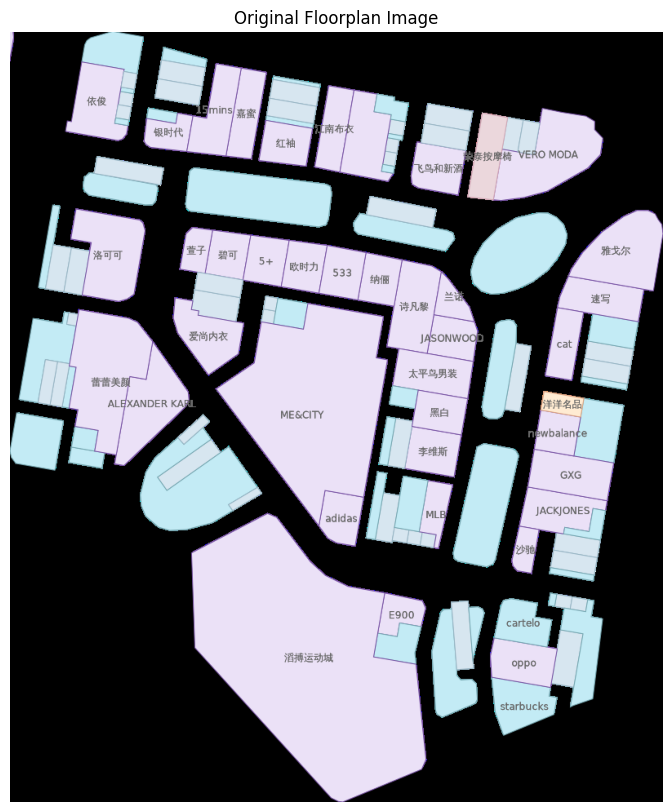

In [174]:
plot_original_image(metadata_root, site, floor)

In [175]:
NUM_POINTS = 2000
EIG_V_DIM = 4

In [176]:
data_root = r"C:/Users/Noa/Documents/GitHub/indoor_localization_research"  # or appropriate path
metadata_root = r"C:/Users/Noa/Documents/GitHub/indoor_localization_research/metadata"
floor_info_path = Path(metadata_root)/site/f"F{floor}" / "floor_info.json"
with open(floor_info_path) as f:
    inf = json.load(f)
width_meter, height_meter = inf["map_info"]["width"], inf["map_info"]["height"]
floor_img = Path(metadata_root)/site/f"F{floor}" / "floor_image.png"

In [366]:
def sample_points_from_img_create_layout_graph(floor, site, metadata_root):
    layout_graph = PhysicalLayoutGraph(floor, site, metadata_root, num_points=NUM_POINTS, embedding_dim=EIG_V_DIM, k=7)
    return layout_graph
    dist_matrix = compute_shortest_paths(layout_graph.G, layout_graph.random_points, layout_graph.circles)
    file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\dist_mat_{site}_{floor}_{NUM_POINTS}_num_points.pkl"
    with open(file_path_name, "wb") as f:
        pickle.dump({'dist_matrix': dist_matrix, 'layout_graph': layout_graph}, f)
    pd.to_pickle(dist_matrix, fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_{NUM_POINTS}points_{NUM_RECIVERS}recivers.pkl")

In [367]:
layout_graph = sample_points_from_img_create_layout_graph(floor, site, metadata_root)

In [292]:
# file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={layout_graph.k}_just_points.pkl"
# with open(file_path_name, "wb") as f:
#     pickle.dump({'layout_graph': layout_graph}, f)

In [293]:
def create_layout_graph():
    layout_graph = PhysicalLayoutGraph(image_path, num_points=NUM_POINTS, embedding_dim=EIG_V_DIM, k=1)
    file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst.pkl"
    with open(file_path_name, "wb") as f:
        pickle.dump({'layout_graph': layout_graph}, f)
    # pd.to_pickle(dist_matrix, fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_{NUM_POINTS}points_{NUM_RECIVERS}recivers.pkl")


def load_layout_graph():
    # path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst.pkl"
    path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={layout_graph.k}_just_points.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
    layout_graph = data['layout_graph']

    if not os.path.exists(path):
        raise FileNotFoundError(f"Distance matrix file not found at {path}")
    return layout_graph

In [294]:
# layout_graph = load_layout_graph()

In [368]:
layout_graph.random_points

array([[ 87, 383],
       [873, 563],
       [713, 651],
       ...,
       [667, 424],
       [153, 299],
       [260, 701]], shape=(2000, 2))

In [369]:
def calibrate_points_to_meters(points, image_shape, width_meter, height_meter):
    """
    Convert (y,x) pixel coordinates to (x,y) in meters.
    Parameters:
        points: ndarray of shape (N,2), with (y,x) pixel coordinates.
        image_shape: tuple (H, W) of the image (in pixels).
        width_meter: width of the map in meters (real-world).
        height_meter: height of the map in meters (real-world).
    Returns:
        calibrated: ndarray of shape (N,2), real-world coordinates in meters.
    """
    H, W = image_shape
    ys, xs = points[:, 0], points[:, 1]

    # Flip y-axis to match top-down view, then scale
    xs_m = xs / W * width_meter
    ys_m = (H - ys) / H * height_meter  # flip y

    return np.column_stack((xs_m, ys_m))  # shape: (N, 2)

In [370]:
# Assume layout_graph.random_points is in (y, x)
image_shape = layout_graph.polygon_mask.shape  # (H, W)
calibrated_points = calibrate_points_to_meters(
    layout_graph.random_points,
    image_shape=image_shape,
    width_meter=width_meter,
    height_meter=height_meter
)


In [371]:
layout_graph.random_points = calibrated_points

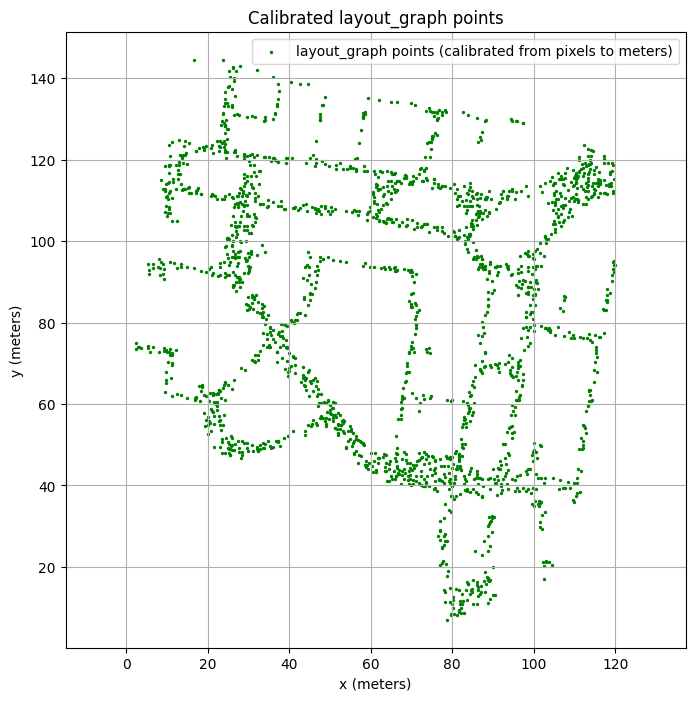

In [372]:
plt.figure(figsize=(8, 8))
plt.scatter(calibrated_points[:, 0], calibrated_points[:, 1], s=2, color="green", label="layout_graph points (calibrated from pixels to meters)")
plt.legend()
plt.title("Calibrated layout_graph points")
plt.xlabel("x (meters)")
plt.ylabel("y (meters)")
plt.grid(True)
plt.axis("equal")
plt.show()

## DO NOT RUN - pre process and clean the signals data

In [251]:
import pandas as pd
from pathlib import Path

def load_filtered_wifi_data(site: str, floor: int, wifi_root: str, split: str = "train") -> pd.DataFrame:
    """
    Load WiFi data for a specific site and floor, remove unwanted columns and invalid rows.
    """
    # Format path
    floor_str = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    csv_path = Path(wifi_root) / split / f"{site}_1000_{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    # Load and filter
    df = pd.read_csv(csv_path)
    print(df.shape)
    print("--------")
    # print(df.iloc[2102:2120,:])
    print("after drop duplicates ", df.drop_duplicates().shape)
    # Drop first column if it's unnamed or empty string
    df = df.drop_duplicates()
    df = df.drop(columns=["Unnamed: 0"])

    df = df[df["f"] == floor]

    cols_to_drop = ["f", "path"]
    # Drop 'f' and 'path' columns
    df = df.drop(columns=cols_to_drop)
    print("after taking just this floor data ", df.shape)
    
    # Drop all -999 columns
    df = df.loc[:, ~(df == -999).all()]
    signals_cols = [col for col in df.columns if col not in {'f', 'path', 'x', 'y'}]
    mask_empty_signals_rows = (df[signals_cols] == -999).all(axis=1)
    print("rows without any signals", df[mask_empty_signals_rows].shape)
    df = df[~mask_empty_signals_rows]
    print("left data", df.shape)
    
    # Replace -999 → -100
    df.replace(-999, -100, inplace=True)

    # Compute and print min/max (excluding -100)
    excluded_cols = {"x", "y"}
    numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=[c for c in excluded_cols if c in df.columns], errors="ignore")    
    if numeric_cols.empty or (numeric_cols.values.flatten() == -100).all():
        print("⚠️ No valid numeric values to compute min/max.")
    else:
        flat_values = numeric_cols.values.flatten()
        filtered = flat_values[flat_values != -100]
        print(f"Max (excluding -100): {filtered.max():.2f}")
        print(f"Min (excluding -100): {filtered.min():.2f}")

    return df


In [252]:
wifi_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\wifi_features"

signals_locations_df = load_filtered_wifi_data(site, floor, wifi_root)


(9296, 946)
--------
after drop duplicates  (9100, 946)
after taking just this floor data  (1198, 943)
rows without any signals (0, 828)
left data (1198, 828)
Max (excluding -100): -27.00
Min (excluding -100): -93.00


In [253]:
signals_locations_df.columns

Index(['000840e5c600de293cea57f13326f273c86c3988',
       '00ad587dcb9c7ce3788b92e22777a22ee0efea31',
       '00af060fc145ee6a6a50475efa57b91cbf54237f',
       '00bcc61bdea4d52d050822d66952dd707c2fcdf3',
       '00f0904087c01d922d6ebf3005607dfdeaf6687b',
       '011e20ebf721a1c6dfec42e8ed1e2ac566073a2a',
       '01e25e4a25acd32baf5137b3031151f751fadbb4',
       '026c2f057932da75680b21ecdbd23bf9cb9350f3',
       '028a310e23177c3747d37971678dd964ee28ce17',
       '02a1be3a5dab38320f879489d8a1e0f2a72768b3',
       ...
       'fd179c5e4fd5e33493ae290adbbda2950ecf0427',
       'fd1a502adb446e835797a88fad8e79d1e0bf4b4a',
       'fd977a3af7be241a9ed0213acb3aa75e5dc00253',
       'fdc189e5a19850397f37201f4acc378cfddcf0d6',
       'fdc19f011587b75c11a6c30d8ca06d90107b6bde',
       'fdf37fa13679f581bdfaae3b99e368633e0a144b',
       'fdfe926caf5f49a88a9bcab8d025e887f422128b',
       'ffa41c79865d7fb336f586e0dec8b080db1027fb', 'x', 'y'],
      dtype='object', length=828)

In [254]:
# signals_locations_df.to_csv(fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\signals_preprocess_cleaned_{site}_F{floor}_.csv")

In [255]:
first_sig = signals_locations_df.columns[3]
col = [first_sig, 'x', "y"]
df_to_scatter = signals_locations_df[col]
df_to_scatter.reset_index(inplace=True, drop=True)

In [256]:
df_to_scatter.rename(columns={first_sig: "signal"}, inplace=True)

C:\Users\Noa\AppData\Local\Temp\ipykernel_8720\3555852978.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



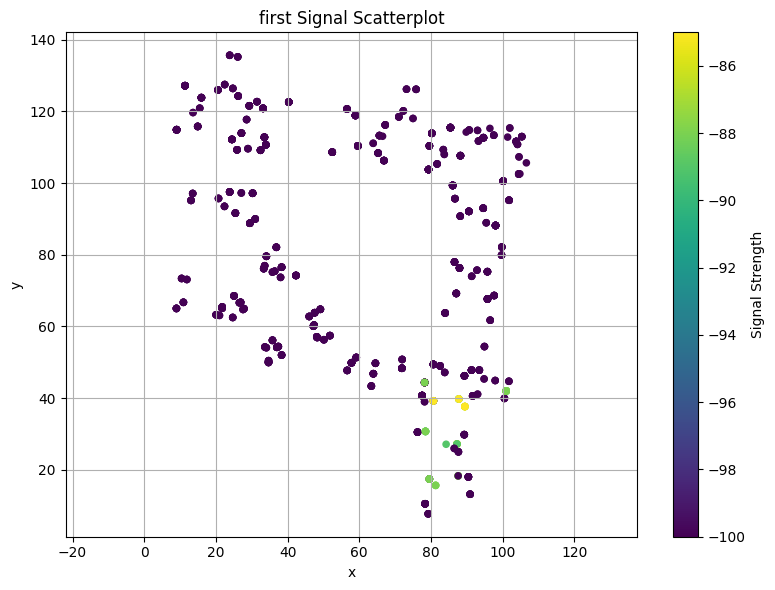

In [257]:
import matplotlib.pyplot as plt

# Assuming df has columns: 'x', 'y', 'signal'
plt.figure(figsize=(8, 6))
sc = plt.scatter(df_to_scatter['x'], df_to_scatter['y'], c=df_to_scatter['signal'], cmap='viridis', s=20)

# Add colorbar to show signal values
plt.colorbar(sc, label='Signal Strength')

# Axis labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('first Signal Scatterplot')

plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


In [258]:
signals_locations_df.index

Index([5876, 5877, 5878, 5879, 5880, 5881, 5882, 5883, 5884, 5885,
       ...
       7064, 7065, 7066, 7067, 7068, 7069, 7070, 7071, 7072, 7073],
      dtype='int64', length=1198)

In [260]:
signals = signals_locations_df.drop(columns=["x","y"])
signals_locations = signals_locations_df[["x","y"]]

# Load signals data

In [373]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path

# --- import the original helper functions from the notebook repo ---  
from data_analysis.io_f import read_data_file    # for reading .txt trace files  
from data_analysis.compute_f import split_ts_seq, compute_step_positions  
from data_analysis.visualize_f import visualize_heatmap  

def build_wifi_fingerprint_df(site: str,
                              floor: int,
                              data_root: str,      # root folder containing train/test .txt files
                              metadata_root: str,  # where floor plan JSON + images are
                              split: str = "train"):
    """
    Build a WiFi fingerprinting DataFrame for a given site & floor,
    by aligning WiFi scans to nearest ground-truth/step positions (x, y).
    """

    # 1. find all trace files for that site & floor
    floor_str = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    folder = Path(data_root) / split / site / floor_str
    txt_files = list(folder.glob("*.txt"))
    if not txt_files:
        raise FileNotFoundError(f"No .txt files found in {folder}")

    rows = []
    all_bssids = set()

    for fpath in txt_files:
        data = read_data_file(str(fpath))
        step_positions = compute_step_positions(data.acce, data.ahrs, data.waypoint)
        wifi_data = data.wifi  # shape: (n_scans, 5) — [timestamp, ..., bssid, rssi]

        if wifi_data.size == 0:
            continue

        # group by unique scan‑timestamp blocks
        for wifi_ds in split_ts_seq(wifi_data, np.unique(wifi_data[:,0].astype(float))):
            ts = float(wifi_ds[0,0])
            # find nearest step position by time
            diffs = np.abs(step_positions[:,0] - ts)
            idx = np.argmin(diffs)
            x, y = step_positions[idx,1], step_positions[idx,2]

            # build a dict: bssid → rssi (mean if multiple within same scan)
            bssid_to_rssi = {}
            for row in wifi_ds:
                bssid = row[2]
                rssi = int(row[3])
                if bssid in bssid_to_rssi:
                    # average if multiple
                    bssid_to_rssi[bssid] = (bssid_to_rssi[bssid] + rssi) / 2
                else:
                    bssid_to_rssi[bssid] = rssi
                all_bssids.add(bssid)

            # append row
            record = {"x": x, "y": y}
            record.update(bssid_to_rssi)
            rows.append(record)

    # 2. build DataFrame
    df = pd.DataFrame(rows)
    df.fillna(-999, inplace=True)  # for missing APs

    print(f"Built fingerprint DF shape: {df.shape} (rows: scans, cols: x,y + {len(all_bssids)} APs)")

    return df

def clean_wifi_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply cleaning similar to your load_filtered_wifi_data:
    - drop columns with all -999
    - drop rows where all signal columns are -999
    - replace -999 → -100
    """
    df = df.copy()
    # drop columns with all -999 (excluding x,y)
    signal_cols = [c for c in df.columns if c not in ("x","y")]
    df = df.drop(columns=[c for c in signal_cols if (df[c] == -999).all()])

    # drop rows where all signal cols are -999
    signal_cols = [c for c in df.columns if c not in ("x","y")]
    mask_all_missing = (df[signal_cols] == -999).all(axis=1)
    df = df.loc[~mask_all_missing].copy()

    # replace -999 with -100
    df[signal_cols] = df[signal_cols].replace(-999, -100)

    return df

# Example usage

data_root = r"C:/Users/Noa/Documents/GitHub/indoor_localization_research"  # or appropriate path
metadata_root = r"C:/Users/Noa/Documents/GitHub/indoor_localization_research/metadata"
out_path = Path(data_root) / "preprocessed_data_thesis" / f"wifi_fp_{site}_{floor}.csv"

# Save cleaned DF
# df_fp = build_wifi_fingerprint_df(site, floor, data_root, metadata_root, split="train")
# df_clean = clean_wifi_df(df_fp)
# df_clean.to_csv(out_path, index=False)
print("Saved cleaned WiFi fingerprint DF to", out_path)


Saved cleaned WiFi fingerprint DF to C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\wifi_fp_5a0546857ecc773753327266_2.csv


In [374]:
df_clean = pd.read_csv(out_path)

In [375]:

# To plot a heatmap (e.g. WiFi count or mean RSSI) : WiFi count
heat_positions = df_clean[['x','y']].values
heat_values = (df_clean.drop(columns=['x','y']) != -100).sum(axis=1).values

# Load floor plan & metadata for plotting
import json
floor_info_path = Path(metadata_root)/site/f"F{floor}" / "floor_info.json"
with open(floor_info_path) as f:
    inf = json.load(f)
width_meter, height_meter = inf["map_info"]["width"], inf["map_info"]["height"]
floor_img = Path(metadata_root)/site/f"F{floor}" / "floor_image.png"

visualize_heatmap(
    heat_positions, heat_values,
    str(floor_img), width_meter, height_meter,
    colorbar_title="WiFi count",
    title=f"WiFi Sum heatmap — site {site}, floor {floor}",
    show=True
)


In [376]:
n_labeled = 50
n_validation = 200

rng = np.random.default_rng(seed=42)

labeled_indices    = list(range(0,n_labeled))

## create signal graph

In [377]:
df_clean.shape

(2268, 1967)

In [378]:
# Shuffle all rows
df_clean = df_clean.sample(frac=1, random_state=42)

# reset the index to 0, 1, 2... after shuffling:
df_clean = df_clean.reset_index(drop=True)

In [379]:
signals_locations_df = df_clean.loc[:, ["x", "y"]]
signals_df = df_clean.drop(columns=["x", "y"])

In [380]:
signals_locations_df.head()

,x,y
0,39.469775,119.940822
1,30.295768,84.945515
2,88.053609,21.655850
3,46.206460,56.107524
4,106.709890,103.974396


## Add labeled signals locations to the random points from layout_graph

In [381]:
labeled_signals_locations = signals_locations_df.iloc[labeled_indices].copy()
random_points_with_labeled_signals = pd.concat([labeled_signals_locations, pd.DataFrame(layout_graph.random_points, columns=["x","y"])], ignore_index=True)
layout_graph.random_points = random_points_with_labeled_signals

In [382]:
layout_graph.random_points.shape

(2050, 2)

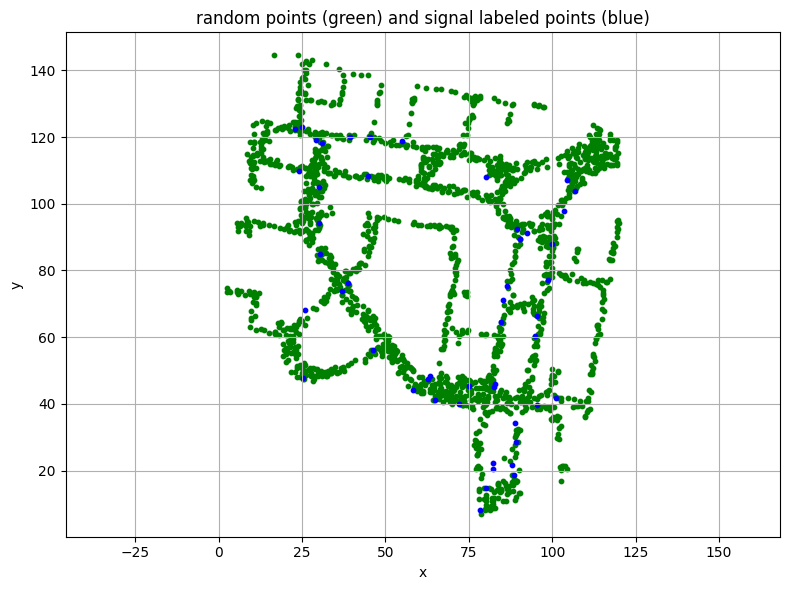

In [383]:
# Assuming df has columns: 'x', 'y', 'signal'
plt.figure(figsize=(8, 6))
plt.scatter(random_points_with_labeled_signals.iloc[50:]['x'], random_points_with_labeled_signals.iloc[50:]['y'],c="green", s=10)
plt.scatter(random_points_with_labeled_signals.iloc[0:50]['x'], random_points_with_labeled_signals.iloc[0:50]['y'],c="blue", s=10)


# Add colorbar to show signal values
# plt.colorbar(sc, label='Signal Strength')

# Axis labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('random points (green) and signal labeled points (blue)')

plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [384]:
layout_graph._build_graph()

✅ created graph: 2050 nodes, 253 edges
nodes: 2050
edges: 253
first 3 nodes: [(0, {'pos': (39.46977527031892, 119.940821807282)}), (1, {'pos': (30.29576809513561, 84.94551532610886)}), (2, {'pos': (88.05360883904146, 21.6558499595997)})]


In [385]:
file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={layout_graph.k}_graph_with_labeled.pkl"
with open(file_path_name, "wb") as f:
    pickle.dump({'layout_graph': layout_graph}, f)

In [386]:
k = layout_graph.k

In [387]:
def load_layout_graph():
    # path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst.pkl"
    path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={k}_graph_with_labeled.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
    layout_graph = data['layout_graph']

    if not os.path.exists(path):
        raise FileNotFoundError(f"Distance matrix file not found at {path}")
    return layout_graph

In [388]:
layout_graph = load_layout_graph()

In [424]:
remaining_indices = np.arange(n_labeled, 1000)

# 3. Randomly choose validation indices from the remaining pool
validation_indices = np.random.choice(remaining_indices, size=n_validation, replace=False)

# Optional: If you want 'all_indices' to be the union of labeled + validation
# (Training on labeled, validating on validation)
train_indices = np.arange(n_labeled)

# Create signal graph

In [390]:
signal_graph = SignalGraph(signals_df, embedding_dim=EIG_V_DIM, k_nearest=7)

SIG: 194.851225027315


In [391]:
signal_graph._compute_embedding(EIG_V_DIM)

In [392]:
signal_graph.embedding.shape

(2268, 4)

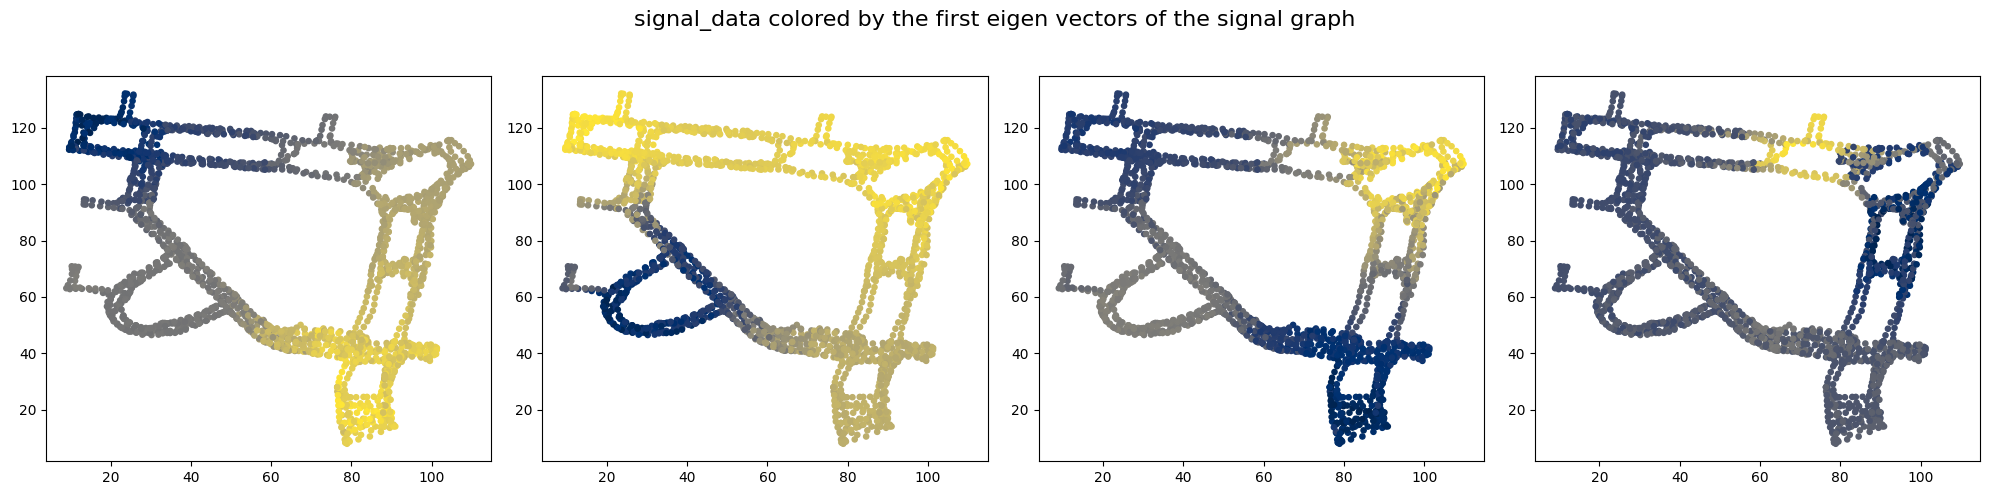

In [393]:
fig,axs = plt.subplots(1,EIG_V_DIM,figsize = (20,5))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(signals_locations_df["x"],signals_locations_df["y"],c = signal_graph.embedding[:,i],s = 14,cmap = 'cividis')


# Add a title to the entire figure
fig.suptitle("signal_data colored by the first eigen vectors of the signal graph", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
plt.show()

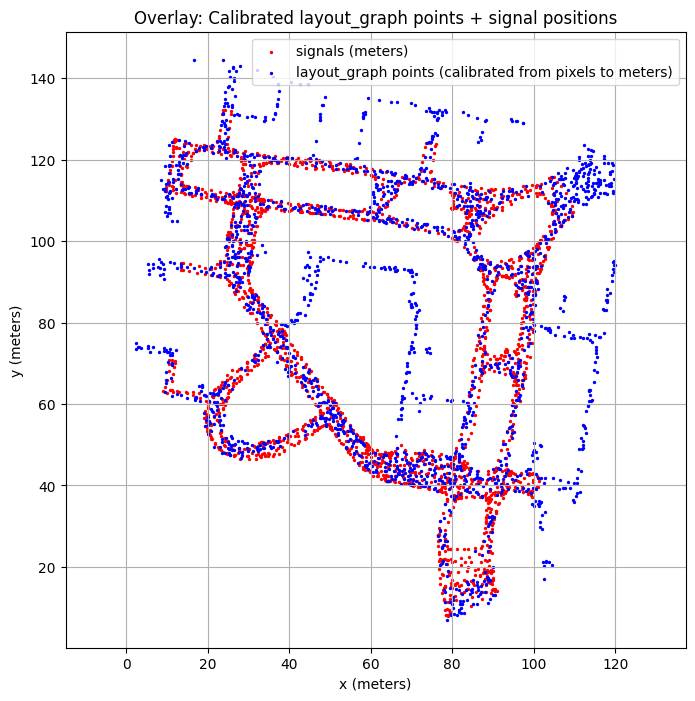

In [394]:
plt.figure(figsize=(8, 8))
plt.scatter(signals_locations_df["x"], signals_locations_df["y"], s=2, color="red", label="signals (meters)")
plt.scatter(calibrated_points[:, 0], calibrated_points[:, 1], s=2, color="blue", label="layout_graph points (calibrated from pixels to meters)")
plt.legend()
plt.title("Overlay: Calibrated layout_graph points + signal positions")
plt.xlabel("x (meters)")
plt.ylabel("y (meters)")
plt.grid(True)
plt.axis("equal")
plt.show()


In [395]:
layout_graph.random_points = pd.DataFrame(layout_graph.random_points, columns=['x',"y"])

In [396]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def slice_points_near_signals(layout_points, signal_points, max_dist=3.0):
    """
    Keep only layout_graph points that have a signal point nearby.

    layout_points: (N,2) array of layout_graph.random_points (meters)
    signal_points: (M,2) array of signal positions (meters)
    max_dist: distance threshold (e.g., 3 meters)

    Returns:
        filtered_layout_points
        mask (boolean mask of kept points)
    """

    nbrs = NearestNeighbors(n_neighbors=1, algorithm='kd_tree').fit(signal_points)
    distances, _ = nbrs.kneighbors(layout_points)

    mask = distances[:, 0] <= max_dist
    return layout_points[mask], mask


In [397]:
filtered_pts, mask = slice_points_near_signals(
    layout_graph.random_points,
    signals_locations_df,
    max_dist=2.0   # tune this (2-5m usually works)
)


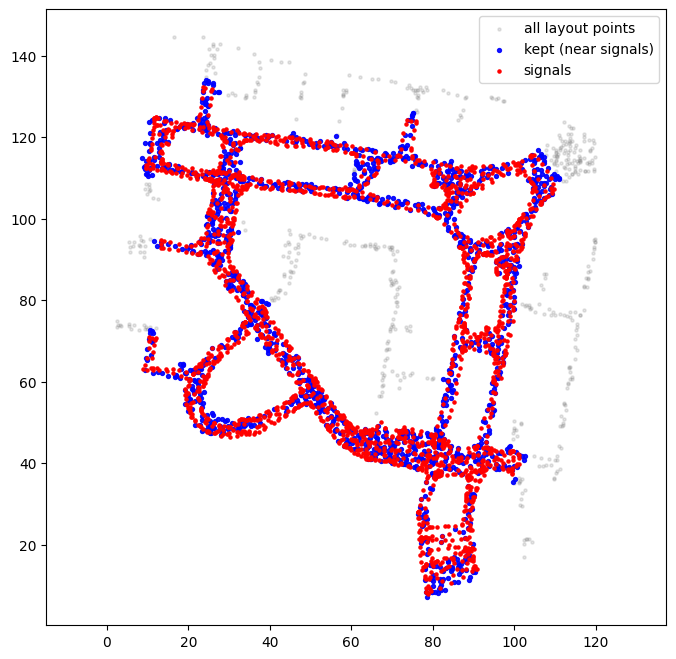

In [398]:
plt.figure(figsize=(8,8))

plt.scatter(layout_graph.random_points.iloc[:,0], 
            layout_graph.random_points.iloc[:,1], 
            s=5, c='gray', alpha=0.2, label='all layout points')

plt.scatter(filtered_pts.iloc[:,0], filtered_pts.iloc[:,1], 
            s=8, c='blue', alpha=0.9, label='kept (near signals)')

plt.scatter(signals_locations_df.iloc[:,0], signals_locations_df.iloc[:,1], 
            s=5, c='red', label='signals')

plt.legend()
plt.axis('equal')
plt.show()


In [399]:
layout_graph.random_points = filtered_pts

In [400]:
layout_graph._compute_adjacency()
layout_graph._compute_embedding()

SIG: 2.0137863419475734
5


In [401]:
layout_graph.embedding.shape

(1577, 4)

In [402]:
signals_locations_df.shape

(2268, 2)

In [403]:
layout_graph.random_points.shape

(1577, 2)

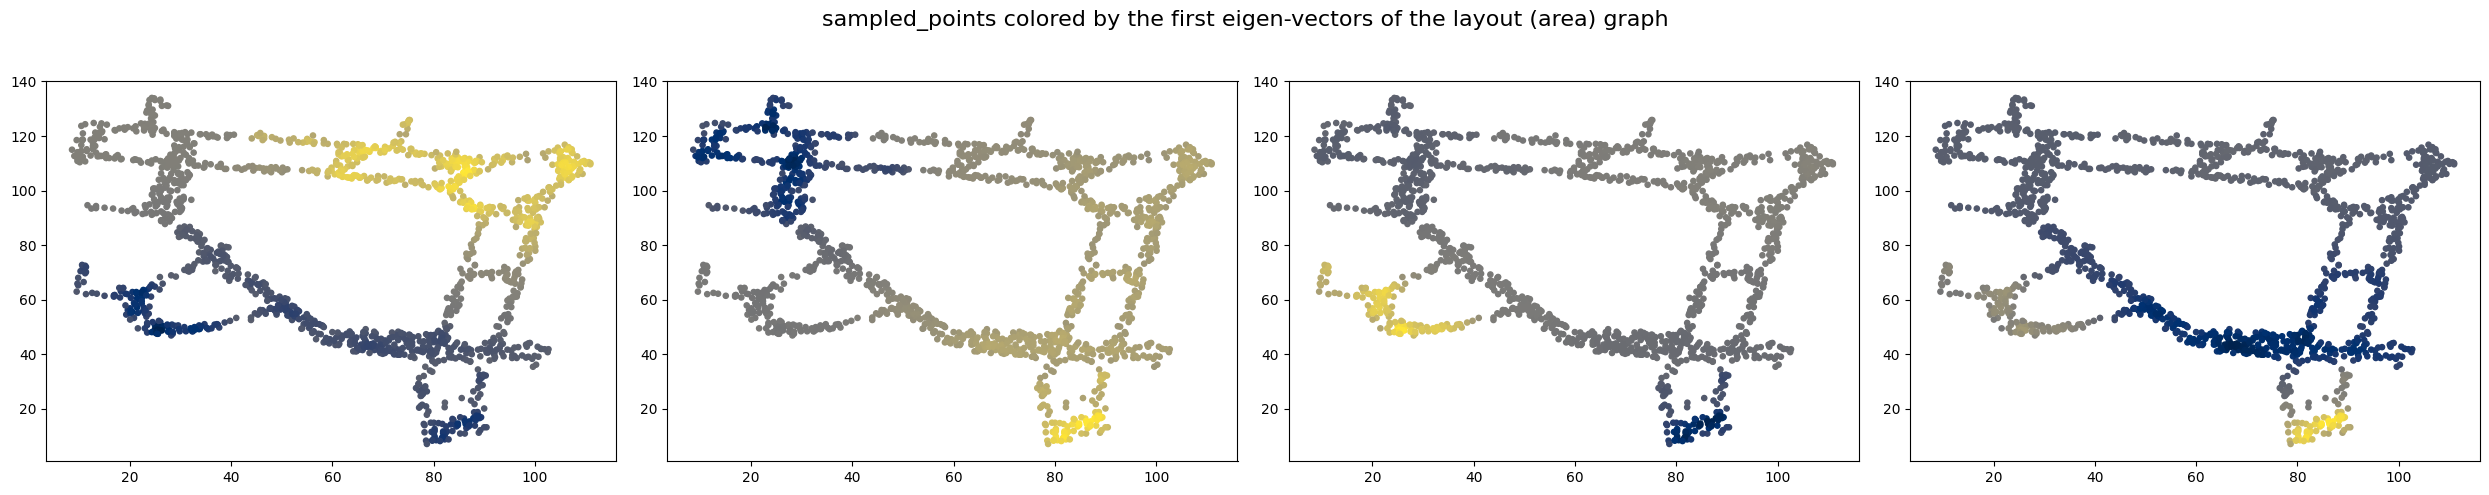

In [404]:
# EIGHEN VECTORS AREA
fig,axs = plt.subplots(1,EIG_V_DIM,figsize = (25,5))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(layout_graph.random_points["x"],layout_graph.random_points["y"],c = layout_graph.embedding[:,i],s = 14,cmap = 'cividis')

# Add a title to the entire figure
fig.suptitle("sampled_points colored by the first eigen-vectors of the layout (area) graph", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
plt.show()


## SSL 

In [425]:
matcher = ManifoldMatcherSSL()
phi_s, centered_A, C, calib_phi_s = matcher.fit(layout_graph, signal_graph, labeled_indices)

phi_S_dim :(50, 4), A_dim:(50, 2), C dim (4, 2), 
[[ 1032.97819164 -1349.78376094]
 [  595.11892542   494.11859706]
 [  306.76575492   659.29066412]
 [ -118.56748239   287.18792668]]


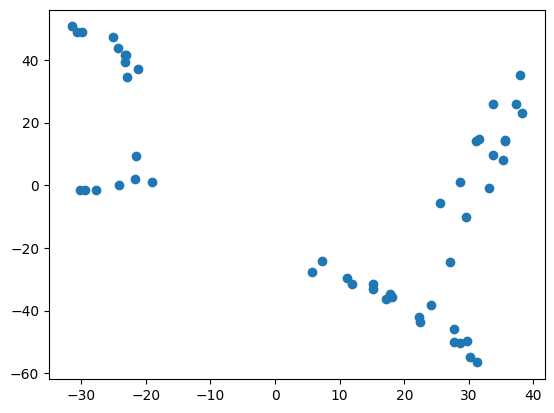

In [426]:
plt.scatter(phi_s @ C[:,0], phi_s @ C[:,1]) 


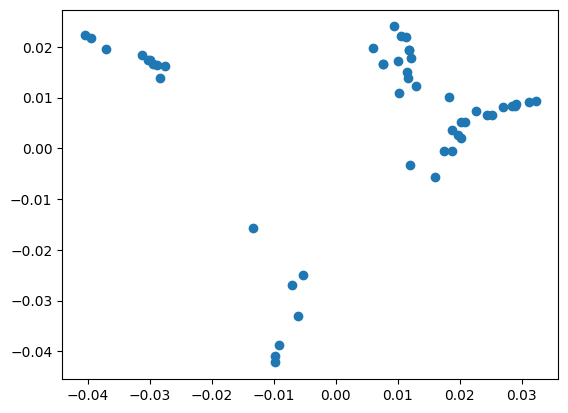

In [427]:
plt.scatter(phi_s[:,0], phi_s[:,1]) 



In [428]:
layout_graph.embedding.shape

(1577, 4)

In [429]:
signal_graph.embedding.shape

(2268, 4)

In [430]:
# Define validation indices (e.g., indices from 20 to 29)
# Make sure these indices are not in labeled_indices

# Important: Add a check to ensure validation_indices do not overlap with labeled_indices
if any(i in labeled_indices for i in validation_indices):
    raise ValueError("Validation indices overlap with labeled indices.")

# Extract signal data and true layout locations for validation points
# validation_data = points_with_signals_df.iloc[validation_indices].copy()
validation_signal_data = signals_df.iloc[validation_indices]
validation_true_real_locations = signals_locations_df.iloc[validation_indices]
validation_signal_data.shape
# Predict locations for the validation signal data
predicted_locations_validation_SSL = matcher.predict(validation_indices)

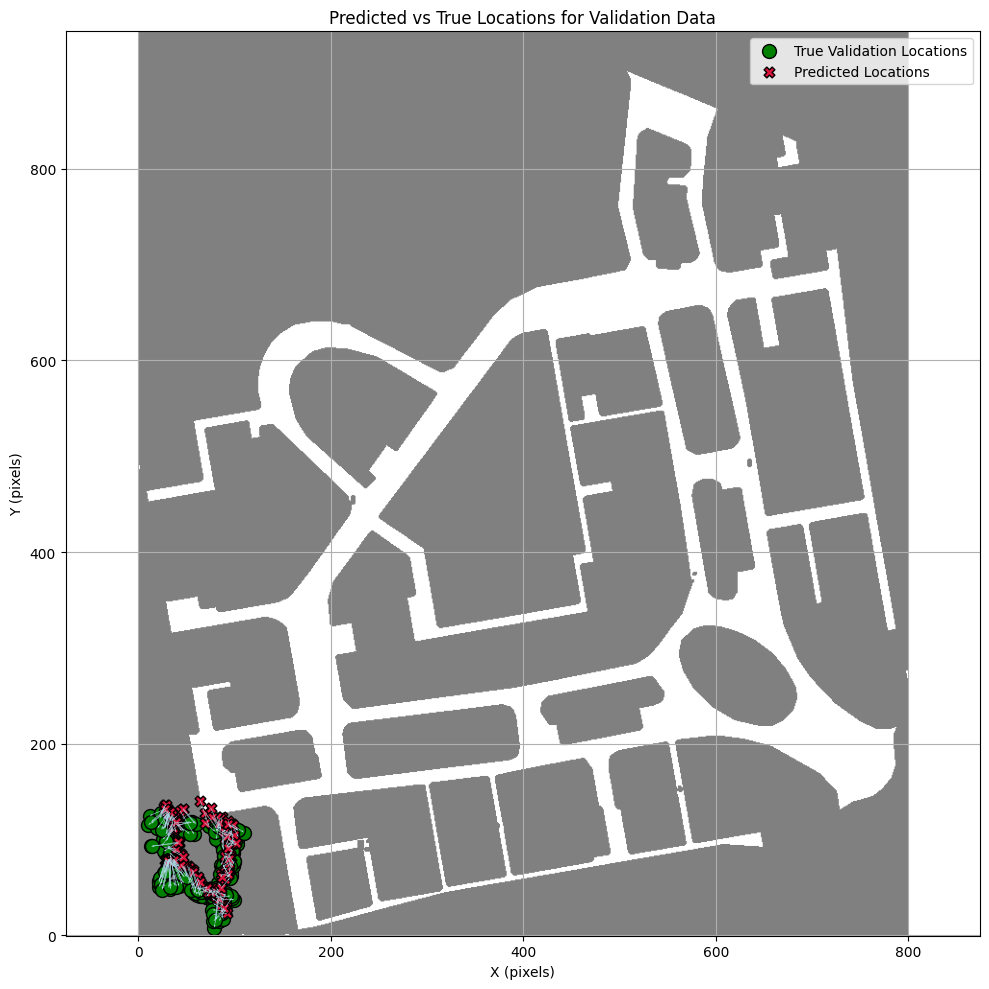

In [431]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

# Show the floor plan mask
plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)

# Plot true validation locations
plt.scatter(
    validation_true_real_locations.iloc[:, 0], 
    validation_true_real_locations.iloc[:, 1], 
    color='green', s=100, label="True Validation Locations", marker='o', edgecolors='black'
)


# Plot predicted validation locations
plt.scatter(
    predicted_locations_validation_SSL[:, 0], 
    predicted_locations_validation_SSL[:, 1], 
    color='crimson', s=60, label='Predicted Locations', marker='X', edgecolors='black'
)

# Compute deltas
dx = validation_true_real_locations.iloc[:, 0] - predicted_locations_validation_SSL[:,0]
dy = validation_true_real_locations.iloc[:, 1] - predicted_locations_validation_SSL[:, 1]

# Draw arrows
plt.quiver(predicted_locations_validation_SSL[:, 0], predicted_locations_validation_SSL[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.0006)

plt.title("Predicted vs True Locations for Validation Data")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()  # Invert Y if origin is top-left as in most images
plt.axis('equal')
plt.tight_layout()
plt.show()


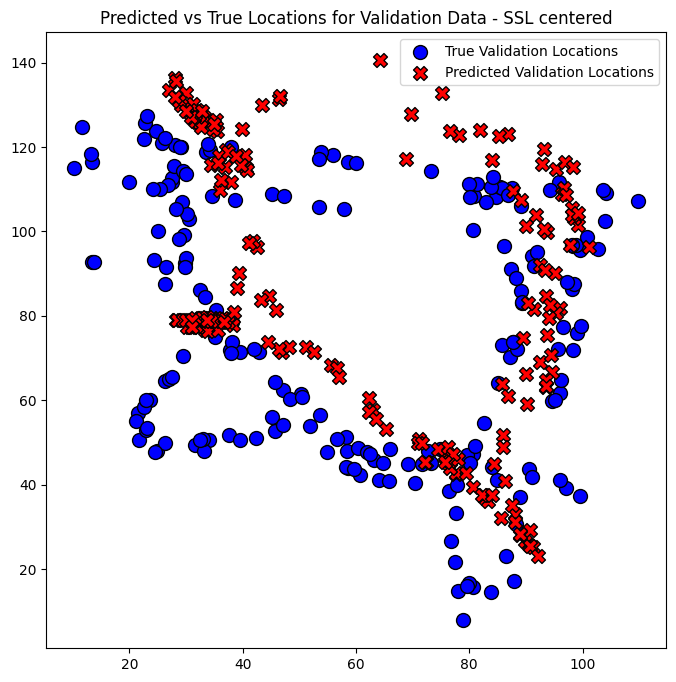

In [432]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
# plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)
# plt.imshow(layout_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations.iloc[:, 0], validation_true_real_locations.iloc[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Compute deltas
dx = validation_true_real_locations.iloc[:, 0] - predicted_locations_validation_SSL[:, 0]
dy = validation_true_real_locations.iloc[:, 1] - predicted_locations_validation_SSL[:, 1]

# Draw arrows
# plt.quiver(predicted_locations_validation_SSL[:, 0], predicted_locations_validation_SSL[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.009)

# Plot the predicted locations of the validation points
plt.scatter(predicted_locations_validation_SSL[:, 0], predicted_locations_validation_SSL[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

plt.legend()
plt.title("Predicted vs True Locations for Validation Data - SSL centered")
plt.show()

# MANIFOLD

In [488]:
manifold = ManifoldMatcher(layout_graph, signal_graph)
phi_S, C_mat, calibrated_phi_s_labeled = manifold.fit(labeled_indices)

phi_S_dim :(50, 4),phi_A_dim:(50, 4), 


In [489]:
#Compute the full calibrated signal embedding for all points
calibrated_phi_s = signal_graph.embedding @ C_mat

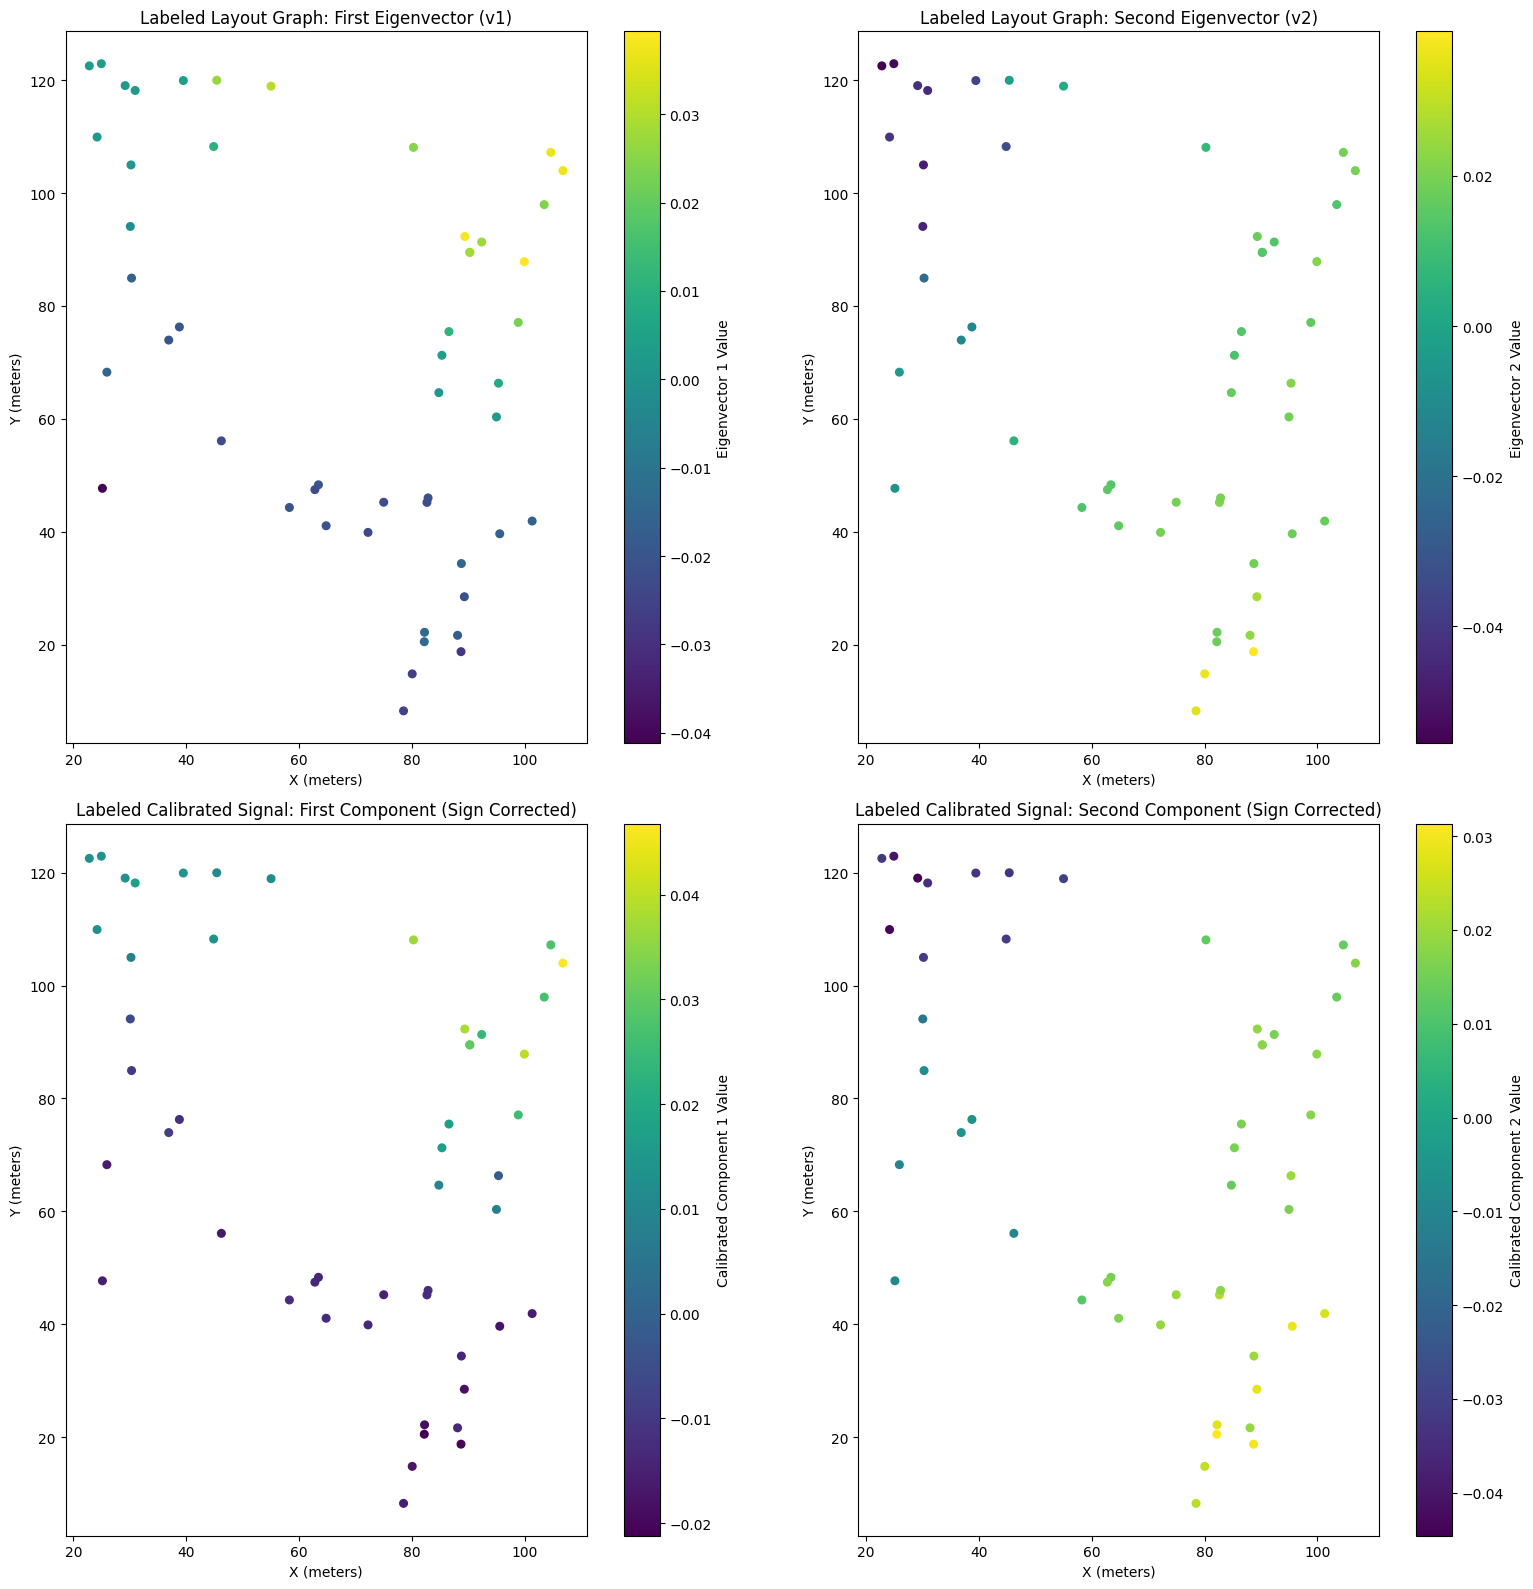

In [490]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Re-deriving variables needed for the plot (assuming they are DataFrames/Arrays) ---

# Assuming area_graph.points is the DataFrame/structure holding the coordinates
layout_full_coords = layout_graph.random_points
layout_full_embedding = layout_graph.embedding
calibrated_full_embedding = calibrated_phi_s # Full calibrated embedding (2268 points)

# Subset the coordinates DataFrame and the embeddings (already done in previous steps)
# Using .iloc for safer row-subsetting on the coordinate DataFrame:
labeled_points_coords = layout_full_coords.iloc[labeled_indices]
layout_v1_labeled = layout_full_embedding[labeled_indices, 0]
layout_v2_labeled = layout_full_embedding[labeled_indices, 1]
calibrated_v1_labeled = calibrated_full_embedding[labeled_indices, 0]
calibrated_v2_labeled = calibrated_full_embedding[labeled_indices, 1]

# Re-calculate correlation and sign for plotting the labeled subset
corr_v1 = np.corrcoef(layout_v1_labeled, calibrated_v1_labeled)[0, 1]
corr_v2 = np.corrcoef(layout_v2_labeled, calibrated_v2_labeled)[0, 1]
calibrated_v1_labeled_aligned = calibrated_v1_labeled * np.sign(corr_v1)
calibrated_v2_labeled_aligned = calibrated_v2_labeled * np.sign(corr_v2)


# --- 2. Corrected Plotting Code using .values ---

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Row 1: Layout Graph Eigenvectors (Labeled Subset)
ax1 = axes[0, 0]
# FIX: Use .values[:, 0] and .values[:, 1] to access NumPy data for X and Y coordinates
sc1 = ax1.scatter(labeled_points_coords.values[:, 0], labeled_points_coords.values[:, 1], 
                  c=layout_v1_labeled, cmap='viridis', s=30)
plt.colorbar(sc1, ax=ax1, label='Eigenvector 1 Value')
ax1.set_title('Labeled Layout Graph: First Eigenvector (v1)')
ax1.set_xlabel('X (meters)')
ax1.set_ylabel('Y (meters)')

ax2 = axes[0, 1]
sc2 = ax2.scatter(labeled_points_coords.values[:, 0], labeled_points_coords.values[:, 1], 
                  c=layout_v2_labeled, cmap='viridis', s=30)
plt.colorbar(sc2, ax=ax2, label='Eigenvector 2 Value')
ax2.set_title('Labeled Layout Graph: Second Eigenvector (v2)')
ax2.set_xlabel('X (meters)')
ax2.set_ylabel('Y (meters)')


# Row 2: Calibrated Signal Embedding Components (Labeled Subset, Sign Corrected)
ax3 = axes[1, 0]
sc3 = ax3.scatter(labeled_points_coords.values[:, 0], labeled_points_coords.values[:, 1], 
                  c=calibrated_v1_labeled_aligned, cmap='viridis', s=30)
plt.colorbar(sc3, ax=ax3, label='Calibrated Component 1 Value')
ax3.set_title('Labeled Calibrated Signal: First Component (Sign Corrected)')
ax3.set_xlabel('X (meters)')
ax3.set_ylabel('Y (meters)')

ax4 = axes[1, 1]
sc4 = ax4.scatter(labeled_points_coords.values[:, 0], labeled_points_coords.values[:, 1], 
                  c=calibrated_v2_labeled_aligned, cmap='viridis', s=30)
plt.colorbar(sc4, ax=ax4, label='Calibrated Component 2 Value')
ax4.set_title('Labeled Calibrated Signal: Second Component (Sign Corrected)')
ax4.set_xlabel('X (meters)')
ax4.set_ylabel('Y (meters)')


for ax in axes.flatten():
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("labeled_embedding_comparison.png")

In [491]:
U, S, Vt = np.linalg.svd(calibrated_phi_s, full_matrices=False)
eigenvectors = Vt.T

In [492]:
eigenvectors

array([[-0.53461507, -0.73822191,  0.40877033, -0.04606471],
       [ 0.79824108, -0.59770559, -0.04235682, -0.06136043],
       [-0.27362048, -0.27678745, -0.88609087, -0.25172109],
       [ 0.04614911,  0.14548243,  0.21437278, -0.96475356]])

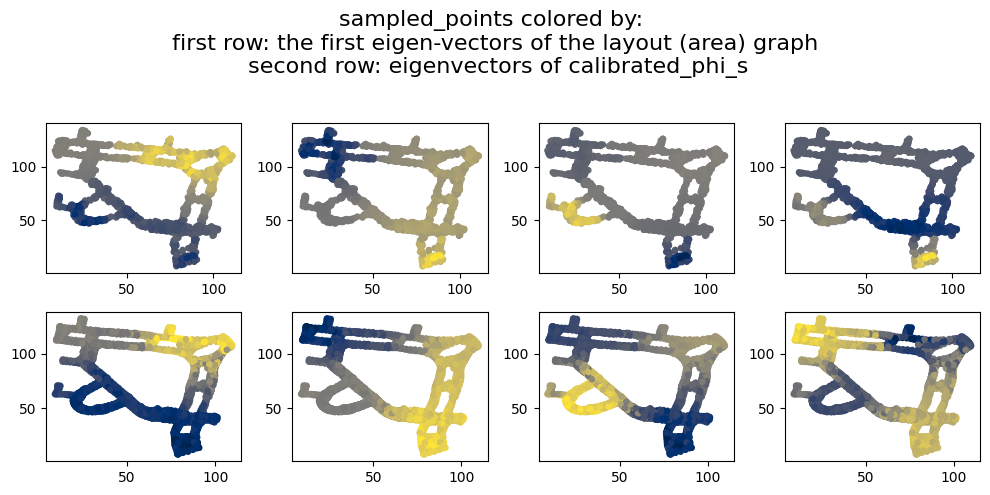

In [493]:
# EIGHEN VECTORS AREA
fig,axs = plt.subplots(2,4,figsize = (10,5))
for i,ax in enumerate(axs.flatten()[0:4]):
    ax.scatter(layout_graph.random_points["x"],layout_graph.random_points["y"],c = layout_graph.embedding[:,i],s = 14,cmap = 'cividis')

for i,ax in enumerate(axs.flatten()[4:8]):
    ax.scatter(signals_locations_df["x"],signals_locations_df["y"],c = calibrated_phi_s[:,i],s = 14,cmap = 'cividis')
# Add a title to the entire figure
fig.suptitle("sampled_points colored by: \n first row: the first eigen-vectors of the layout (area) graph \n second row: eigenvectors of calibrated_phi_s", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
plt.show()

In [494]:
import numpy as np

# We assume the graph objects and the embedding dimension are available:
# layout_graph, signal_graph, EMBEDDING_DIM (which seems to be 4)

# --- Check Layout Graph Eigenvalues ---
# Assuming layout_graph.L is the normalized Laplacian matrix
# Assuming EMBEDDING_DIM = 4

# The function must be called with EMBEDDING_DIM + 1 to include the trivial eigenvector (lambda_0)
lam_A, v_A = compute_leading_eigenvectors(layout_graph.L, EMBEDDING_DIM + 1)

print("\n--- Layout Graph (L_A) Largest Eigenvalues ---")
print(f"Lambda 0 (Trivial): {lam_A[0]:.6f}")
print(f"Lambda 1 (1st Non-Trivial): {lam_A[1]:.6f}")
print(f"Lambda 2 (2nd Non-Trivial): {lam_A[2]:.6f}")
print(f"Lambda 3 (3rd Non-Trivial): {lam_A[3]:.6f}")
print(f"Lambda 4 (4th Non-Trivial): {lam_A[4]:.6f}")
print("-" * 40)

# --- Check Signal Graph Eigenvalues ---
# Assuming signal_graph.L is the normalized Laplacian matrix
lam_S, v_S = compute_leading_eigenvectors(signal_graph.L, EMBEDDING_DIM + 1)

print("\n--- Signal Graph (L_S) Largest Eigenvalues ---")
print(f"Lambda 0 (Trivial): {lam_S[0]:.6f}")
print(f"Lambda 1 (1st Non-Trivial): {lam_S[1]:.6f}")
print(f"Lambda 2 (2nd Non-Trivial): {lam_S[2]:.6f}")
print(f"Lambda 3 (3rd Non-Trivial): {lam_S[3]:.6f}")
print(f"Lambda 4 (4th Non-Trivial): {lam_S[4]:.6f}")

# You are looking for a clear separation: Lambda 0 >> Lambda 1 > Lambda 2 > ...


--- Layout Graph (L_A) Largest Eigenvalues ---
Lambda 0 (Trivial): 1.000000
Lambda 1 (1st Non-Trivial): 0.999869
Lambda 2 (2nd Non-Trivial): 0.999805
Lambda 3 (3rd Non-Trivial): 0.999705
Lambda 4 (4th Non-Trivial): 0.999520
----------------------------------------

--- Signal Graph (L_S) Largest Eigenvalues ---
Lambda 0 (Trivial): 1.000000
Lambda 1 (1st Non-Trivial): 0.979379
Lambda 2 (2nd Non-Trivial): 0.973787
Lambda 3 (3rd Non-Trivial): 0.944030
Lambda 4 (4th Non-Trivial): 0.821542


In [495]:
validation_indices

array([766,  55, 615, 171, 168, 212, 339, 303, 257, 504, 660, 235, 204,
       165, 986, 605, 698, 464, 906, 478, 497, 813, 909, 420, 432, 945,
       319,  59, 540, 347, 875, 541, 686, 877, 523, 490, 521, 416, 920,
       248, 305, 448, 575, 758, 574, 674, 530, 996, 567, 295, 501, 857,
       242, 643, 722, 582, 941, 619, 447, 531, 217, 238, 654, 991, 688,
       100, 135, 426, 981, 320, 910, 729, 995, 388, 903, 862, 366, 554,
       452, 922, 881, 901, 700, 819, 395, 905, 458, 978, 134, 591, 980,
       512, 387,  50, 202, 293, 987, 576, 691, 137, 252, 826, 670, 860,
       969, 482, 297, 355, 930, 302, 167, 624, 974,  89, 913, 117, 123,
       677, 446, 360, 632, 714, 760, 132, 560, 266, 151, 247, 653, 790,
       558, 777, 429, 522,  93, 953, 594, 899, 141, 873, 833, 985, 552,
       301, 488, 327, 358,  79, 793,  56, 453, 353, 761, 336, 345, 216,
       610, 792, 807, 568, 607, 984, 115, 931, 244, 116, 516, 867, 751,
       883, 444,  72, 578, 407, 392, 210, 487, 779, 352, 422, 14

In [496]:
layout_graph.random_points

,x,y
0,39.469775,119.940822
1,30.295768,84.945515
2,88.053609,21.655850
3,46.206460,56.107524
4,106.709890,103.974396
...,...,...
2045,49.266081,58.027866
2046,79.560130,40.573574
2047,64.872106,42.410868
2048,45.747075,121.108291


In [497]:
# Important: Add a check to ensure validation_indices do not overlap with labeled_indices
if any(i in labeled_indices for i in validation_indices):
    raise ValueError("Validation indices overlap with labeled indices.")

# Extract signal data and true layout locations for validation points
validation_data = layout_graph.random_points.iloc[validation_indices].copy()
validation_signal_data = validation_data.drop(['x', 'y'], axis=1).values
validation_true_real_locations = validation_data[['x', 'y']].values
# validation_true_real_locations = pd.DataFrame(validation_true_real_locations)
validation_signal_data.shape

# Predict locations for the validation signal data
predicted_locations_validation_manifold = manifold.predict(validation_indices, 3)

(200, 4)
(4, 4)


In [498]:
type(validation_true_real_locations)

numpy.ndarray

In [499]:
validation_true_real_locations

array([[ 30.14104928,  93.70199006],
       [ 21.11403452, 123.5580163 ],
       [ 37.94406203,  79.76917781],
       [ 27.23404452, 111.0031745 ],
       [ 24.78604052, 127.5388198 ],
       [ 20.65503377, 122.79247717],
       [ 50.03108179,  58.6402977 ],
       [ 73.44012006,  40.87978978],
       [ 70.38011506, 116.05573279],
       [  9.63901576, 114.06533104],
       [ 81.70213357,  46.6978872 ],
       [ 29.98804903,  83.29065783],
       [ 82.16113432,   8.72714613],
       [ 90.72914833, 107.78791013],
       [ 61.50610055, 106.10372404],
       [ 13.92302276, 112.68736059],
       [ 56.4570923 , 117.73991888],
       [ 89.19914582,  94.31442137],
       [ 88.74014507,  27.55940884],
       [ 10.55701726, 118.65856584],
       [ 55.8450913 ,  50.83179853],
       [ 87.21014257,  70.5827082 ],
       [ 98.53216108,  88.64943177],
       [ 50.49008254, 107.48169448],
       [ 63.1891033 , 111.46249798],
       [ 83.69113682,  11.78930267],
       [ 77.11212606,  41.33911326],
 

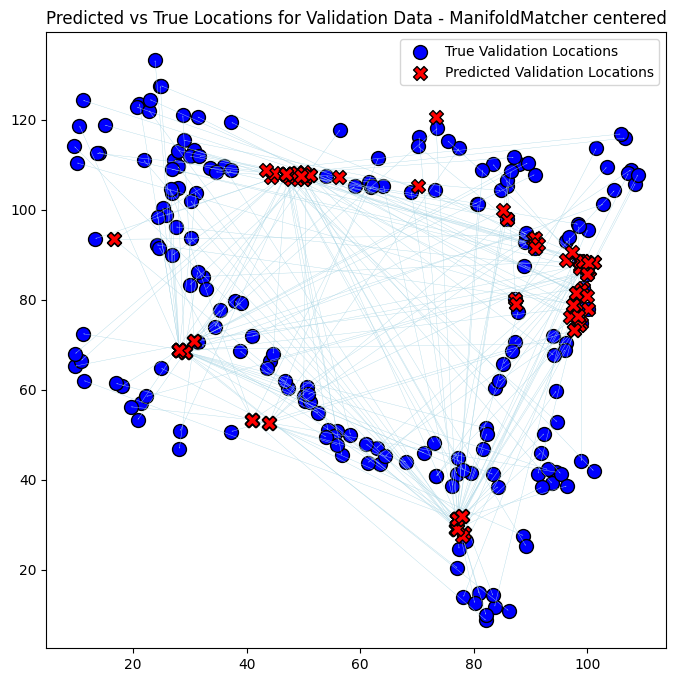

In [500]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
# plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)
# plt.imshow(layout_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations[:, 0], validation_true_real_locations[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Compute deltas
dx = validation_true_real_locations[:, 0] - predicted_locations_validation_manifold.iloc[:, 0]
dy = validation_true_real_locations[:, 1] - predicted_locations_validation_manifold.iloc[:, 1]

# Draw arrows
plt.quiver(predicted_locations_validation_manifold.iloc[:, 0], predicted_locations_validation_manifold.iloc[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.0006)

# Plot the predicted locations of the validation points
plt.scatter(predicted_locations_validation_manifold.iloc[:, 0], predicted_locations_validation_manifold.iloc[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

plt.legend()
plt.title("Predicted vs True Locations for Validation Data - ManifoldMatcher centered")
plt.show()

# Auto Encoder 

In [19]:
class SignalAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], bottleneck_dim=2):
        super().__init__()
        # Encoder
        layers = []
        last_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(last_dim, h))
            layers.append(nn.ReLU())
            last_dim = h
        layers.append(nn.Linear(last_dim, bottleneck_dim))  # bottleneck
        self.encoder = nn.Sequential(*layers)

        # Decoder
        decoder_layers = []
        last_dim = bottleneck_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(last_dim, h))
            decoder_layers.append(nn.ReLU())
            last_dim = h
        decoder_layers.append(nn.Linear(last_dim, input_dim))  # output
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

In [26]:
class AutoencoderMatcher:
    def __init__(self, signal_graph, layout_graph, device='cpu'):
        self.signal_graph = signal_graph
        self.layout_graph = layout_graph
        self.device = device

    def fit(self, labeled_indices, epochs=200, lr=1e-3, alpha=1.0):
        """
        Train autoencoder with combined reconstruction and alignment loss.
        alpha: weight for alignment loss
        """
        X = torch.tensor(self.signal_graph.signal_data, dtype=torch.float32).to(self.device)
        Y = torch.tensor(self.layout_graph.get_points(), dtype=torch.float32).to(self.device)
        y_labeled = Y[labeled_indices]
        x_labeled = X[labeled_indices]

        self.model = SignalAutoencoder(X.shape[1]).to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        for epoch in range(epochs):
            optimizer.zero_grad()
            x_hat, z = self.model(X)
            z_labeled = z[labeled_indices]

            recon_loss = loss_fn(x_hat, X)
            align_loss = loss_fn(z_labeled, y_labeled[:, :2])  # target is 2D projection
            loss = recon_loss + alpha * align_loss
            loss.backward()
            optimizer.step()

    def predict(self, validation_indices):
        """
        Returns 2D latent codes for given signal validation points
        """
        self.model.eval()
        X = torch.tensor(self.signal_graph.signal_data, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            z = self.model.encoder(X)
        return z[validation_indices].cpu().numpy()


In [33]:
matcher = AutoencoderMatcher(signal_graph, area_graph)

In [34]:
labeled_indices_fit = [i for i in range(50)] 
matcher.fit(labeled_indices=labeled_indices_fit, epochs=300, alpha=10.0)


In [ ]:
pred_2d = matcher.predict(validation_indices=validation_indices)

In [36]:
validation_data = pd.DataFrame(data = area_graph.get_points(),columns=['x', 'y']).iloc[validation_indices].copy()
validation_signal_data = validation_data.drop(['x', 'y'], axis=1).values
validation_true_real_locations_AE = validation_data[['x', 'y']].values

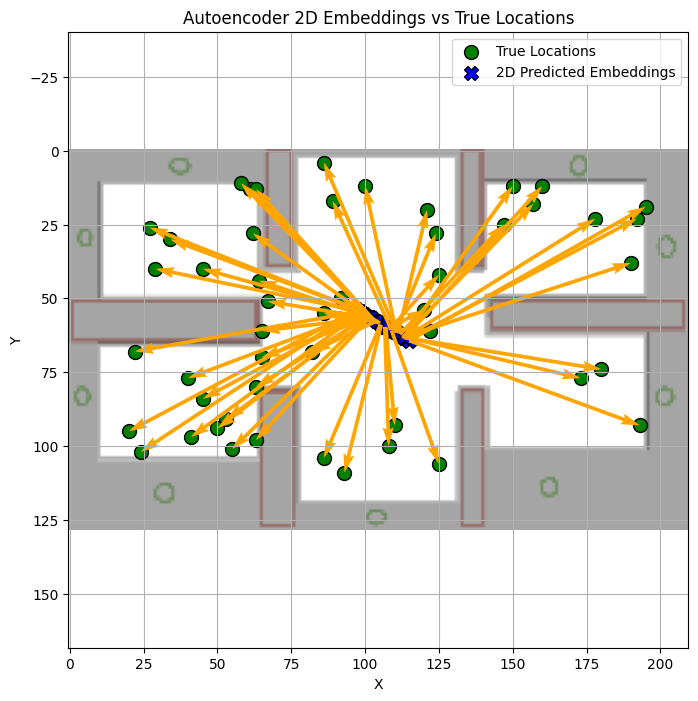

In [38]:
# Plot the 2D predictions vs true real locations
plt.figure(figsize=(8, 8))
plt.imshow(area_graph.polygon_mask, cmap='gray', alpha=0.5)
plt.imshow(area_graph.image, alpha=0.3)

# Plot the true real-world locations
plt.scatter(validation_true_real_locations_AE[:, 0], validation_true_real_locations_AE[:, 1],
            color='green', s=100, label="True Locations", marker='o', edgecolor='black')

# Plot the 2D predictions from the autoencoder
plt.scatter(pred_2d[:, 0], pred_2d[:, 1],
            color='blue', s=100, label="2D Predicted Embeddings", marker='X', edgecolor='black')

# Compute the delta vectors
dx = validation_true_real_locations_AE[:, 0] - pred_2d[:, 0]
dy = validation_true_real_locations_AE[:, 1] - pred_2d[:, 1]

# Draw arrows from prediction to ground truth
plt.quiver(pred_2d[:, 0], pred_2d[:, 1], dx, dy,
           angles='xy', scale_units='xy', scale=1,
           color='orange', width=0.006)

plt.legend()
plt.title("Autoencoder 2D Embeddings vs True Locations")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn

class SignalAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64]):
        super(SignalAutoencoder, self).__init__()

        # Encoder to 2D
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], 2)
        )

        # Decoder from 2D back to original input
        self.decoder = nn.Sequential(
            nn.Linear(2, hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class AutoencoderMatcher:
    def __init__(self, signal_graph, layout_graph):
        self.signal_graph = signal_graph
        self.layout_graph = layout_graph
        self.device = torch.device('cpu')  # Force CPU usage

    def fit(self, labeled_indices, epochs=200, lr=1e-3, alpha=1.0):
        """
        Trains autoencoder using:
        - Reconstruction loss on all data
        - Alignment loss between 2D latent codes and real 2D locations for labeled points
        """
        # Full signal data (N x D)
        X = torch.tensor(self.signal_graph.signal_data, dtype=torch.float32).to(self.device)
        Y = torch.tensor(self.layout_graph.get_points(), dtype=torch.float32).to(self.device)

        x_labeled = X[labeled_indices]
        y_labeled = Y[labeled_indices, :2]  # only 2D locations for alignment

        self.model = SignalAutoencoder(input_dim=X.shape[1]).to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        for epoch in range(epochs):
            self.model.train()
            optimizer.zero_grad()

            x_hat, z = self.model(X)
            z_labeled = z[labeled_indices]

            recon_loss = loss_fn(x_hat, X)
            align_loss = loss_fn(z_labeled, y_labeled)
            total_loss = recon_loss + alpha * align_loss

            total_loss.backward()
            optimizer.step()

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:3d} | Recon: {recon_loss.item():.4f} | Align: {align_loss.item():.4f} | Total: {total_loss.item():.4f}")

    def predict(self, validation_indices):
        """
        Returns 2D latent codes (z) for given signal validation points
        """
        self.model.eval()
        X = torch.tensor(self.signal_graph.signal_data, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            z = self.model.encoder(X)
        return z[validation_indices].cpu().numpy()




In [46]:
matcher = AutoencoderMatcher(signal_graph, area_graph)
matcher.fit(labeled_indices=labeled_indices_fit, epochs=200, lr=1e-3, alpha=0.5)
pred_2d = matcher.predict(validation_indices=validation_indices)

Epoch   0 | Recon Loss: 92.1456 | Align Loss: 9255.0645 | Total: 4719.6777
Epoch  10 | Recon Loss: 77.4243 | Align Loss: 8420.0283 | Total: 4287.4385
Epoch  20 | Recon Loss: 19.3381 | Align Loss: 7316.1558 | Total: 3677.4160
Epoch  30 | Recon Loss: 40.3203 | Align Loss: 5677.8198 | Total: 2879.2302
Epoch  40 | Recon Loss: 10.2404 | Align Loss: 3741.8848 | Total: 1881.1827
Epoch  50 | Recon Loss: 3.7092 | Align Loss: 2258.1868 | Total: 1132.8026
Epoch  60 | Recon Loss: 1.5201 | Align Loss: 2030.3655 | Total: 1016.7029
Epoch  70 | Recon Loss: 1.4025 | Align Loss: 1967.6683 | Total: 985.2366
Epoch  80 | Recon Loss: 1.2002 | Align Loss: 1897.3187 | Total: 949.8596
Epoch  90 | Recon Loss: 1.2191 | Align Loss: 1880.3500 | Total: 941.3941
Epoch 100 | Recon Loss: 1.1886 | Align Loss: 1845.5557 | Total: 923.9664
Epoch 110 | Recon Loss: 1.2046 | Align Loss: 1819.7561 | Total: 911.0827
Epoch 120 | Recon Loss: 1.2336 | Align Loss: 1791.3560 | Total: 896.9116
Epoch 130 | Recon Loss: 1.2675 | Align 

In [47]:
validation_data = pd.DataFrame(data = area_graph.get_points(),columns=['x', 'y']).iloc[validation_indices].copy()
validation_signal_data = validation_data.drop(['x', 'y'], axis=1).values
validation_true_real_locations_AE = validation_data[['x', 'y']].values

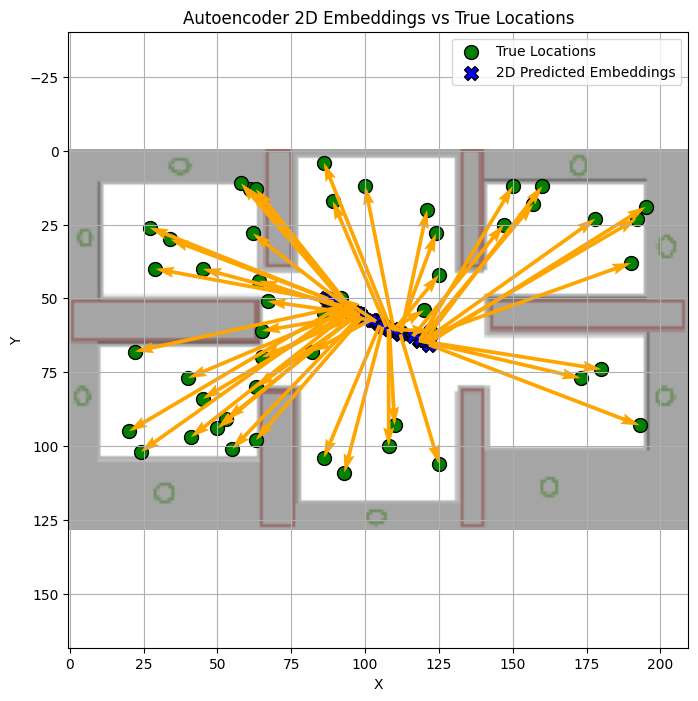

In [48]:
# Plot the 2D predictions vs true real locations
plt.figure(figsize=(8, 8))
plt.imshow(area_graph.polygon_mask, cmap='gray', alpha=0.5)
plt.imshow(area_graph.image, alpha=0.3)

# Plot the true real-world locations
plt.scatter(validation_true_real_locations_AE[:, 0], validation_true_real_locations_AE[:, 1],
            color='green', s=100, label="True Locations", marker='o', edgecolor='black')

# Plot the 2D predictions from the autoencoder
plt.scatter(pred_2d[:, 0], pred_2d[:, 1],
            color='blue', s=100, label="2D Predicted Embeddings", marker='X', edgecolor='black')

# Compute the delta vectors
dx = validation_true_real_locations_AE[:, 0] - pred_2d[:, 0]
dy = validation_true_real_locations_AE[:, 1] - pred_2d[:, 1]

# Draw arrows from prediction to ground truth
plt.quiver(pred_2d[:, 0], pred_2d[:, 1], dx, dy,
           angles='xy', scale_units='xy', scale=1,
           color='orange', width=0.006)

plt.legend()
plt.title("Autoencoder 2D Embeddings vs True Locations")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)
plt.show()


# Cross Validation

In [41]:
def run_loocv_gridsearch(layout_graph, signal_graph, labeled_indices, l_dims, s_dims):
    """
    Run LOOCV across grid of layout and signal embedding dimensions.

    Args:
        layout_graph: PhysicalLayoutGraph instance
        signal_graph: SignalGraph instance
        labeled_indices: list of shared indices used for CV
        l_dims: list of layout embedding dimensions to try
        s_dims: list of signal embedding dimensions to try

    Returns:
        error_matrix: 2D array of shape (len(l_dims), len(s_dims))
        best_params: tuple (best_l_dim, best_s_dim)
    """
    error_matrix = np.zeros((len(l_dims), len(s_dims)))

    for i, l_dim in enumerate(l_dims):
        layout_graph._compute_embedding(l_dim)

        for j, s_dim in enumerate(s_dims):
            signal_graph._compute_embedding(s_dim)

            errors = []
            for k in range(len(labeled_indices)):
                val_idx = labeled_indices[k]
                train_idx = labeled_indices[:k] + labeled_indices[k+1:]

                matcher = ManifoldMatcher(layout_graph=layout_graph, signal_graph=signal_graph)
                matcher.fit(train_idx)
                pred = matcher.predict([val_idx])[0]
                true = layout_graph.get_points()[val_idx]
                error = np.linalg.norm(pred - true)
                errors.append(error)

            mean_error = np.mean(errors)
            error_matrix[i, j] = mean_error
            print(f"l={l_dim}, s={s_dim} → LOOCV error: {mean_error:.2f}")

    # Find best parameters
    best_idx = np.unravel_index(np.argmin(error_matrix), error_matrix.shape)
    best_l = l_dims[best_idx[0]]
    best_s = s_dims[best_idx[1]]

    return error_matrix, (best_l, best_s)


In [42]:
l_dims = [2,3, 4,5,6]
s_dims = [2,3,4,5,6]
shared_indices = list(range(60)) 

error_matrix, best_params = run_loocv_gridsearch(area_graph, signal_graph, shared_indices, l_dims, s_dims)
print("Best parameters:", best_params)


3
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2),

In [43]:
def plot_cv_heatmap(error_matrix, l_dims, s_dims):
    # Convert to numpy arrays for indexing
    l_dims = np.array(l_dims)
    s_dims = np.array(s_dims)

    # Sort by l_dims descending (row-wise)
    sort_idx = np.argsort(l_dims)[::-1]
    error_matrix_sorted = error_matrix[sort_idx, :]
    l_dims_sorted = l_dims[sort_idx]

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        error_matrix_sorted,
        annot=True, fmt=".2f",
        xticklabels=s_dims,
        yticklabels=l_dims_sorted,
        cmap="viridis"
    )
    ax.set_xlabel("Signal Embedding Dimension (s_dim)")
    ax.set_ylabel("Layout Embedding Dimension (l_dim)")
    ax.set_title("LOOCV Error Heatmap")
    plt.tight_layout()
    plt.show()


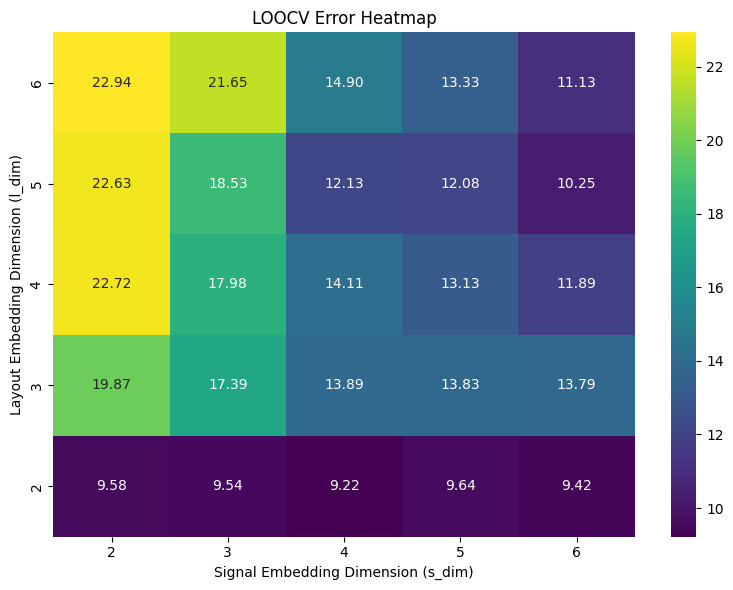

In [44]:
plot_cv_heatmap(error_matrix, l_dims, s_dims)

In [45]:
def run_cv_fixed_train_size(layout_graph, signal_graph, shared_indices, l_dims, s_dims, train_size=20, val_sizes=[30, 50, 80, 100]):
    """
    Perform cross-validation with fixed training size and varying validation sizes.

    Returns:
        results: list of dicts, each with:
            {
                'val_size': int,
                'best_error': float,
                'best_l': int,
                'best_s': int,
                'error_matrix': np.ndarray of shape (len(l_dims), len(s_dims))
            }
    """
    np.random.seed(42)
    shared_indices = np.array(shared_indices)
    results = []

    for val_size in val_sizes:
        if train_size + val_size > len(shared_indices):
            raise ValueError("train_size + val_size exceeds number of available points")

        # Subsample training + validation indices
        chosen_indices = np.random.choice(shared_indices, train_size + val_size, replace=False)
        train_idx = chosen_indices[:train_size]
        val_idx = chosen_indices[train_size:]

        error_matrix = np.zeros((len(l_dims), len(s_dims)))

        for i, l_dim in enumerate(l_dims):
            for j, s_dim in enumerate(s_dims):
                # Set embeddings
                layout_graph._compute_embedding(l_dim)
                signal_graph._compute_embedding(s_dim)

                matcher = ManifoldMatcher(layout_graph, signal_graph)
                matcher.fit(train_idx)
                pred = matcher.predict( val_idx)
                true = layout_graph.get_points()[val_idx]
                error = np.linalg.norm(pred - true, axis=1).mean()
                error_matrix[i, j] = error

        best_i, best_j = np.unravel_index(np.argmin(error_matrix), error_matrix.shape)
        results.append({
            'val_size': val_size,
            'best_error': error_matrix[best_i, best_j],
            'best_l': l_dims[best_i],
            'best_s': s_dims[best_j],
            'error_matrix': error_matrix
        })

    return results


In [46]:
import matplotlib.pyplot as plt

def plot_cv_vs_val_size(results):
    """
    Plot Best LOOCV Error vs Validation Size
    """
    val_sizes = [r['val_size'] for r in results]
    best_errors = [r['best_error'] for r in results]

    plt.figure(figsize=(8, 5))
    plt.plot(val_sizes, best_errors, marker='o')
    plt.title("Best LOOCV Error vs Validation Set Size")
    plt.xlabel("Validation Set Size")
    plt.ylabel("Mean LOOCV Error")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [47]:
l_dims = [2, 3, 4]
s_dims = [2, 3, 4]
val_sizes = [20,50,100,200]
shared_indices = list(range(NUM_POINTS)) 
results = run_cv_fixed_train_size(area_graph, signal_graph, shared_indices, l_dims, s_dims, train_size=20, val_sizes=val_sizes)


3
phi_S_dim :(20, 2), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 3), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 4), A_emb_dim:(20, 2), 
4
phi_S_dim :(20, 2), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 3), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 4), A_emb_dim:(20, 3), 
5
phi_S_dim :(20, 2), A_emb_dim:(20, 4), 
5
phi_S_dim :(20, 3), A_emb_dim:(20, 4), 
5
phi_S_dim :(20, 4), A_emb_dim:(20, 4), 
3
phi_S_dim :(20, 2), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 3), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 4), A_emb_dim:(20, 2), 
4
phi_S_dim :(20, 2), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 3), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 4), A_emb_dim:(20, 3), 
5
phi_S_dim :(20, 2), A_emb_dim:(20, 4), 
5
phi_S_dim :(20, 3), A_emb_dim:(20, 4), 
5
phi_S_dim :(20, 4), A_emb_dim:(20, 4), 
3
phi_S_dim :(20, 2), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 3), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 4), A_emb_dim:(20, 2), 
4
phi_S_dim :(20, 2), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 3), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 4), A_emb_dim:(2

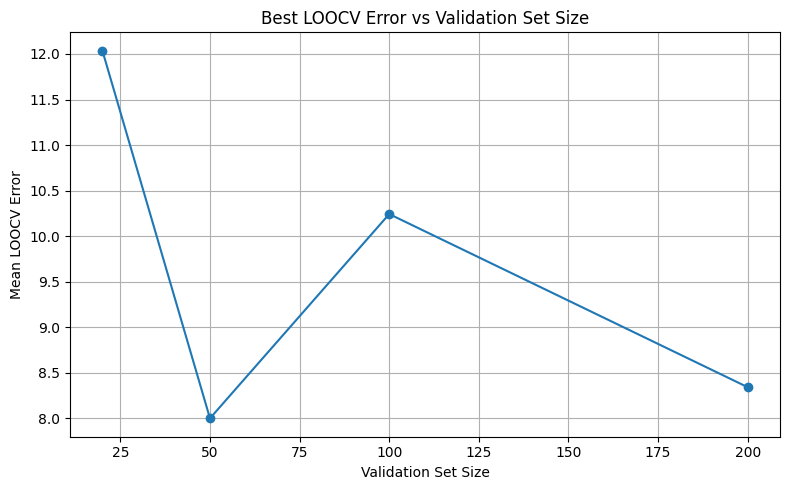

In [48]:
plot_cv_vs_val_size(results)

In [49]:
def plot_loocv_lines(results_list, l_dims, s_dims, val_sizes):
    """
    Plot a line for each validation size showing best LOOCV error vs layout dimension (l_dim).

    Args:
        results_list: list of result dicts from run_cv_fixed_train_size
        l_dims: list of layout embedding dimensions tested
        s_dims: list of signal embedding dimensions tested
        val_sizes: list of validation sizes (must match length of results_list)
    """
    for val_size, result in zip(val_sizes, results_list):
        error_matrix = result['error_matrix']  # shape: (len(l_dims), len(s_dims))

        # Get the best error per l_dim (min over s_dims for each row)
        best_errors = error_matrix.min(axis=1)

        plt.plot(l_dims, best_errors, marker='o', label=f'Val Size {val_size}')

    plt.xlabel("Layout Embedding Dimension (l_dim)")
    plt.ylabel("Mean LOOCV Error")
    plt.title("LOOCV Error vs Layout Dim for Varying Validation Sizes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


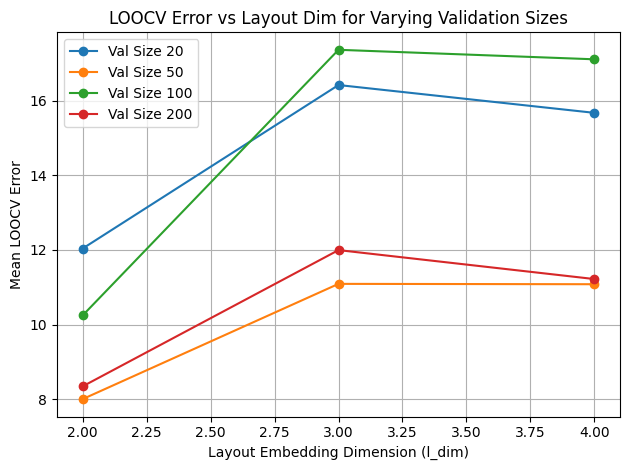

In [50]:
plot_loocv_lines(results, l_dims, s_dims, val_sizes)

In [51]:
def plot_loocv_lines_val(val_sizes, results_list, l_dims, s_dims):
    """
    Plot a line for each (l_dim, s_dim) pair showing LOOCV error vs validation set size.

    Args:
        val_sizes: list of validation sizes
        results_list: list of results from run_cv_fixed_train_size (one per val_size)
        l_dims: list of layout embedding dimensions
        s_dims: list of signal embedding dimensions
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Prepare color cycle
    plt.figure(figsize=(10, 6))

    # For each (l_dim, s_dim) pair
    for i, l in enumerate(l_dims):
        for j, s in enumerate(s_dims):
            errors = [res['error_matrix'][i, j] for res in results_list]
            plt.plot(val_sizes, errors, marker='o', label=f"(l={l}, s={s})")

    plt.xlabel("Validation Set Size")
    plt.ylabel("LOOCV Error")
    plt.title("LOOCV Error vs Validation Set Size for Each (l_dim, s_dim)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


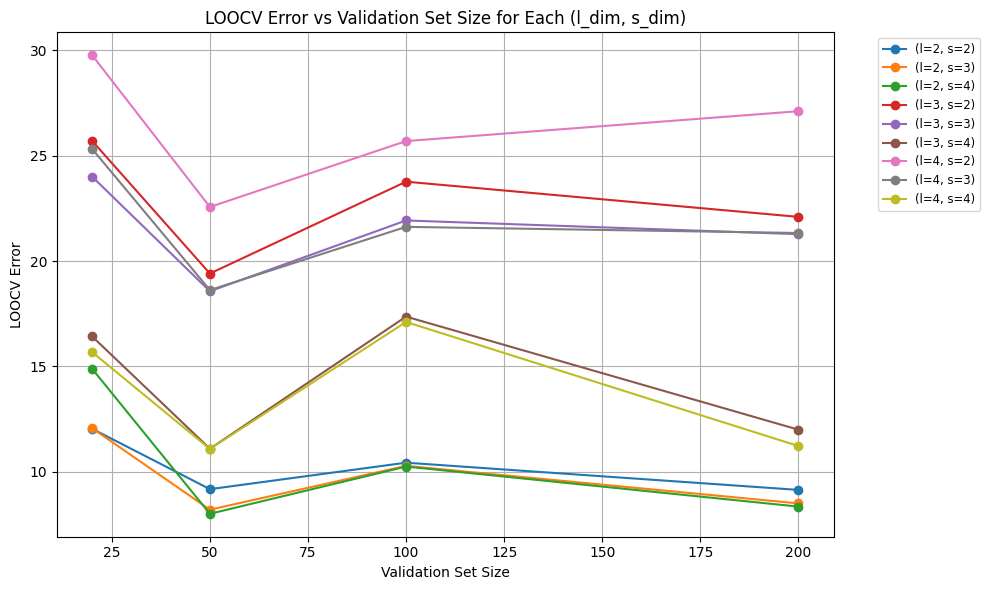

In [52]:
plot_loocv_lines_val(val_sizes, results, l_dims, s_dims)


SSL vs MM (comparison number of labeled points) 

# SSL vs MM : Validation Error against number of labeled points 

In [53]:
def run_cv_varying_train_size(layout_graph, signal_graph, shared_indices, l_dim, s_dim, train_sizes, val_size):
    """
    Cross-validation with varying number of labeled (training) points.
    For each train size, compares SSL and standard Manifold Matching.

    Args:
        layout_graph: instance of PhysicalLayoutGraph
        signal_graph: instance of SignalGraph
        shared_indices: list of indices with known correspondence
        l_dim: fixed layout embedding dimension
        s_dim: fixed signal embedding dimension
        train_sizes: list of integers (number of labeled points)
        val_size: number of validation points (held out)

    Returns:
        results: list of dicts, each containing:
            {
                'train_size': int,
                'ssl_error': float,
                'mm_error': float
            }
    """

    # np.random.seed(42)
    shared_indices = np.array(shared_indices)
    results = []

    # Compute embeddings
    layout_graph._compute_embedding(l_dim)
    signal_graph._compute_embedding(s_dim)
    
    for train_size in train_sizes:
        if train_size + val_size > len(shared_indices):
            raise ValueError(f"train_size + val_size exceeds number of shared points: {train_size + val_size} > {len(shared_indices)}")

        # Subsample shared indices
        # selected_indices = np.random.choice(shared_indices, train_size + val_size, replace=False)
        train_idx = shared_indices[:train_size]
        val_idx = shared_indices[-val_size:]

        # ---- SSL ----
        ssl = MatcherSSL()
        ssl.fit(layout_graph, signal_graph, labeled_indices=train_idx)
        ssl_pred = ssl.predict(val_idx)
        ssl_true = layout_graph.get_points()[val_idx]
        ssl_error = np.mean(np.linalg.norm(ssl_pred - ssl_true, axis=1))

        # ---- Manifold Matching ----
        mm = ManifoldMatcher(layout_graph, signal_graph)
        mm.fit(train_idx)
        mm_pred = mm.predict(val_idx)
        mm_true = layout_graph.get_points()[val_idx]
        mm_error = np.mean(np.linalg.norm(mm_pred - mm_true, axis=1))

        results.append({
            'train_size': train_size,
            'ssl_error': ssl_error,
            'mm_error': mm_error
        })

    return results


In [54]:
val_size = 500

l_dim, s_dim = 2,3
labeled_point_counts = [1,3, 5,7, 10,12, 15, 18,20, 30,50]

results = run_cv_varying_train_size(area_graph, signal_graph, shared_indices, l_dim, s_dim, labeled_point_counts, val_size)


3
phi_S_dim :(1, 3), A_dim:(1, 2), C dim (3, 2), 
[[ 979.75727096 -352.524285  ]
 [ -84.29958546   30.33164639]
 [-730.40038374  262.8037379 ]]
phi_S_dim :(1, 3), A_emb_dim:(1, 2), 
phi_S_dim :(3, 3), A_dim:(3, 2), C dim (3, 2), 
[[ 1290.6692322   -619.87438203]
 [ -291.47823666 -1478.83582146]
 [ -289.43220213    78.36241979]]
phi_S_dim :(3, 3), A_emb_dim:(3, 2), 
phi_S_dim :(5, 3), A_dim:(5, 2), C dim (3, 2), 
[[ 1640.11158613  -132.32392153]
 [   42.1597229  -1012.93654119]
 [ -208.1602697    327.55641382]]
phi_S_dim :(5, 3), A_emb_dim:(5, 2), 
phi_S_dim :(7, 3), A_dim:(7, 2), C dim (3, 2), 
[[ 1.63827885e+03 -1.47428840e+02]
 [ 1.27965145e+00 -9.00311479e+02]
 [-1.71940070e+02  2.39488577e+02]]
phi_S_dim :(7, 3), A_emb_dim:(7, 2), 
phi_S_dim :(10, 3), A_dim:(10, 2), C dim (3, 2), 
[[ 1.58774937e+03 -8.39471735e+01]
 [-1.43884008e-01 -1.01464610e+03]
 [-1.12321093e+02  1.72384256e+02]]
phi_S_dim :(10, 3), A_emb_dim:(10, 2), 
phi_S_dim :(12, 3), A_dim:(12, 2), C dim (3, 2), 
[[ 1573.

In [55]:
def plot_validation_error_vs_labeled_points(results):
    """
    Plot validation error vs number of labeled points for both SSL and Manifold Matching.

    Args:
        results: list of dicts, each with keys:
            'train_size' (int), 'ssl_error' (float), 'mm_error' (float)
    """
    train_sizes = [r['train_size'] for r in results]
    ssl_errors = [r['ssl_error'] for r in results]
    mm_errors = [r['mm_error'] for r in results]

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, ssl_errors, marker='o', label='SSL', linestyle='-', linewidth=2)
    plt.plot(train_sizes, mm_errors, marker='s', label='Manifold Matching', linestyle='--', linewidth=2)
    plt.xlabel("Number of Labeled Points")
    plt.ylabel("Validation Error")
    plt.title("Validation Error vs Number of Labeled Points")
    plt.grid(True)
    plt.legend()
    plt.xticks(train_sizes)  
    plt.tight_layout()
    plt.show()


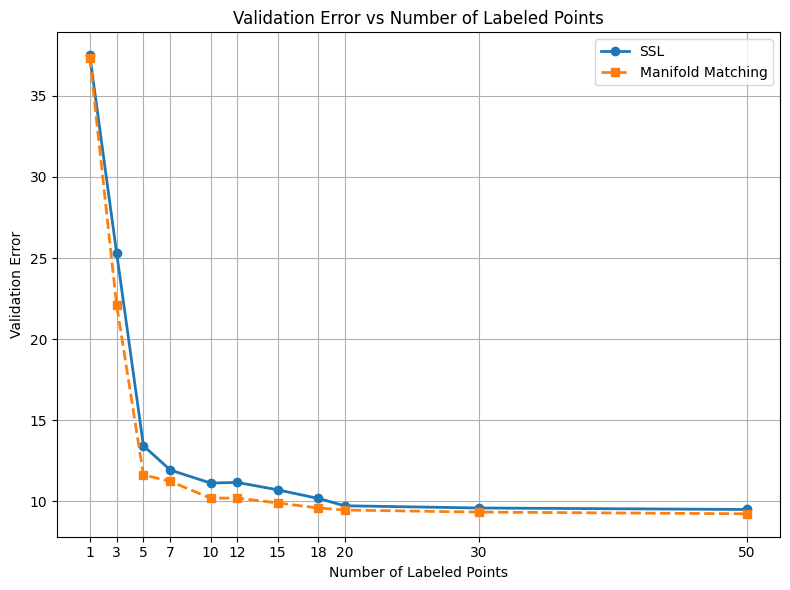

In [56]:
plot_validation_error_vs_labeled_points(results)
